## Comprehensive Model Evaluation on Test Data
 
### This notebook loads all previously trained models and evaluates them on the master test set (`data/master_splits/test_set.parquet`). It performs the following steps for each model:

### 1.  **Loads the required test data and labels.**
### 2.  **Loads the trained model artifacts** from the `models/` directory.
### 3.  **Generates predictions** on the unseen test data.
### 4.  **Calculates and displays key performance metrics** (Classification Report, Accuracy, ROC-AUC, etc.).
### 5.  **Generates and saves all evaluation plots** (Confusion Matrix, Feature Importance, etc.) to the `results/` directory.

### This provides a complete, end-to-end performance summary of the entire trained pipeline.

In [1]:
# ===================================================================
# CELL 1: SETUP AND IMPORTS
# ===================================================================
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder

# --- Import all project-specific classes and configurations ---
# This assumes the notebook is in the root of your project directory.
from config import Config
from data_loader import (
    get_data_for_binary, get_data_for_multiclass, get_data_for_virus,
    load_master_test_set, IoTDataset
)
from binary_classifier import BinaryClassifier
from multiclass_classifier import MultiClassXGBoost, MultiClassNeuralNetModel
from virus_classifier import VirusClassifier
from autoencoder import AutoencoderModel
from autoencoder_denoising import DenoisingAutoencoderModel
from clustering import KMeansClustering

# Ensure the results directory exists
os.makedirs(Config.RESULTS_DIR, exist_ok=True)

# Set seeds and print mode info for consistency
Config.set_seeds()
Config.print_mode_info()

# ## 1. Binary Classification: Benign vs. Malicious
# 
# Here, we evaluate the performance of the tuned LightGBM model and the baseline logistic regression model on the binary task of identifying traffic as either benign or malicious.


/Users/arun-ghontale/UB/Personal Projects/dic_phase2/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



⚙️  CONFIGURATION MODE
   Mode: TEST MODE 🧪
   Raw Data Directory: data/raw_test/
   Device: mps


Evaluating Binary Classification Models

🔧 PREPARING BINARY CLASSIFICATION DATA

📂 Loading MASTER TRAIN set from: data/master_splits/train_set.parquet
✓ Loaded 61,336 training samples.

📂 Loading MASTER TEST set from: data/master_splits/test_set.parquet
✓ Loaded 15,335 test samples.
✓ Binary data ready.
  - Train samples: 61,336
  - Test samples:  15,335

--- Evaluating: Tuned LightGBM ---

ADVANCED MODEL: Tuned LightGBM
Binary Classifier (LightGBM) initialized
  Using Optuna: True
  Using SMOTE: True
✓ Model loaded from models/binary_classifier_tuned.pkl

📊 EVALUATING ADVANCED LightGBM MODEL
✓ Predictions complete (0.07s)

──────────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99       365
   Malicious       1.00      1.00      1.00     14970

    accuracy                           1

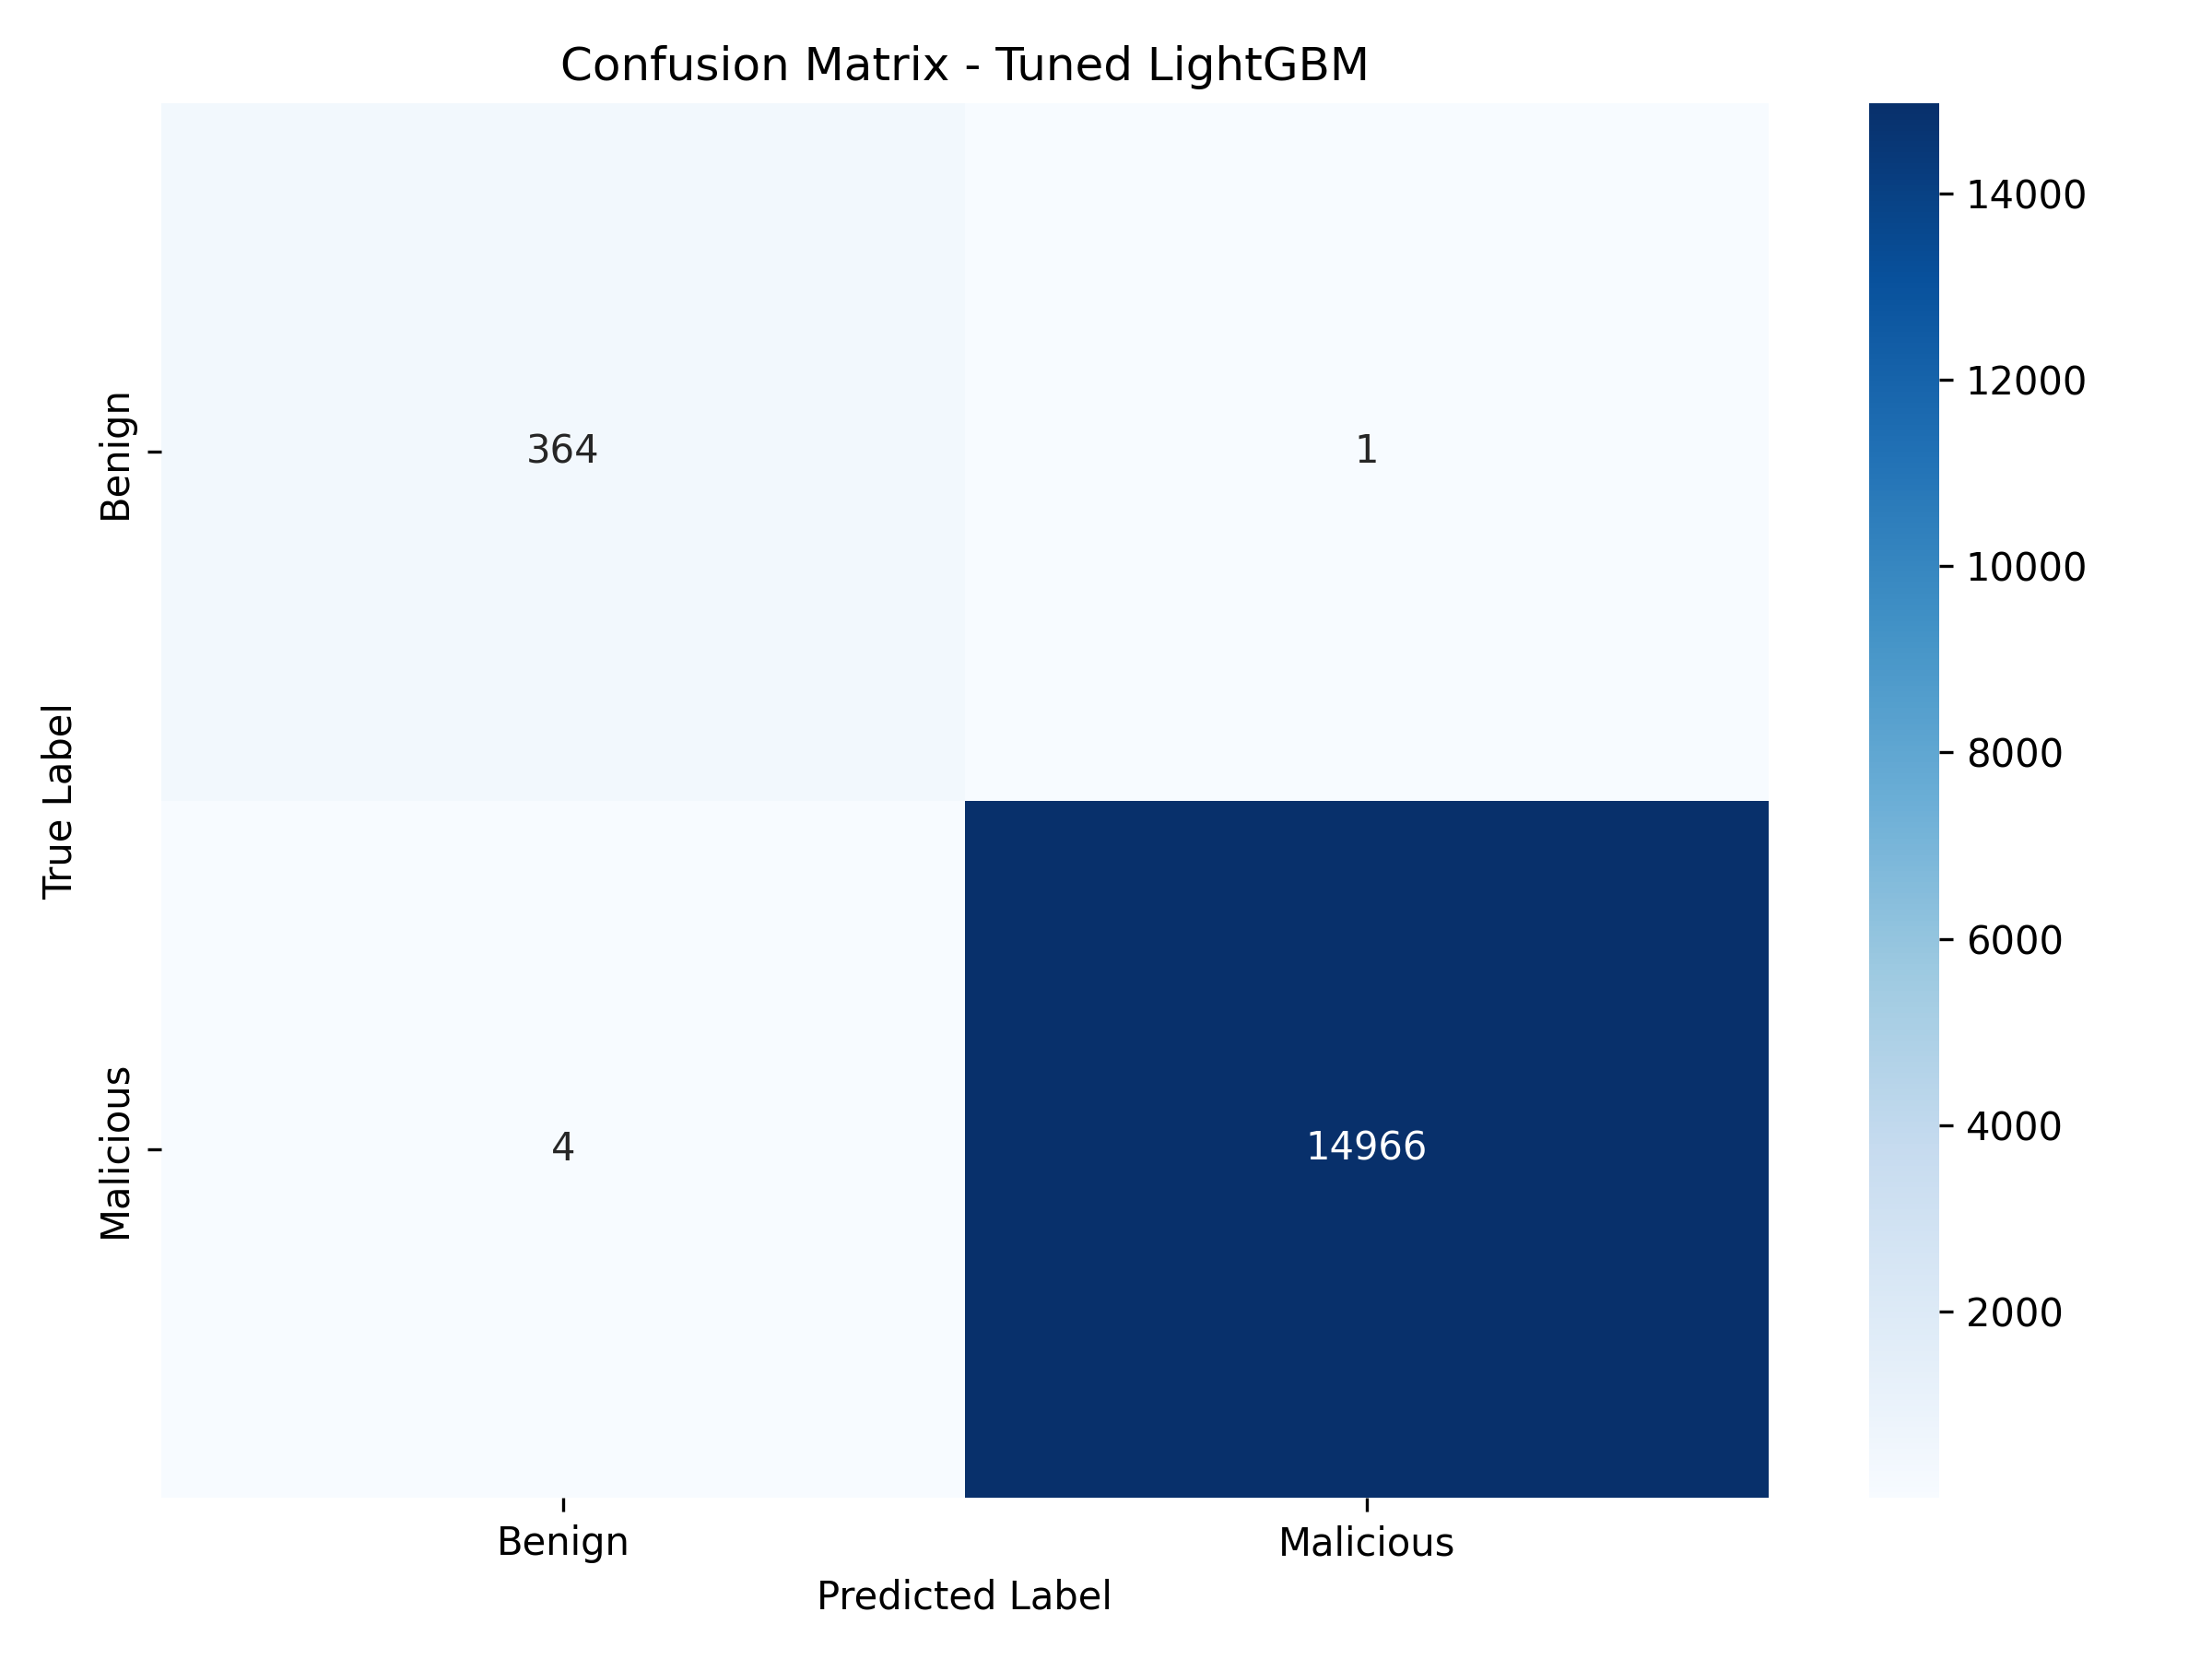

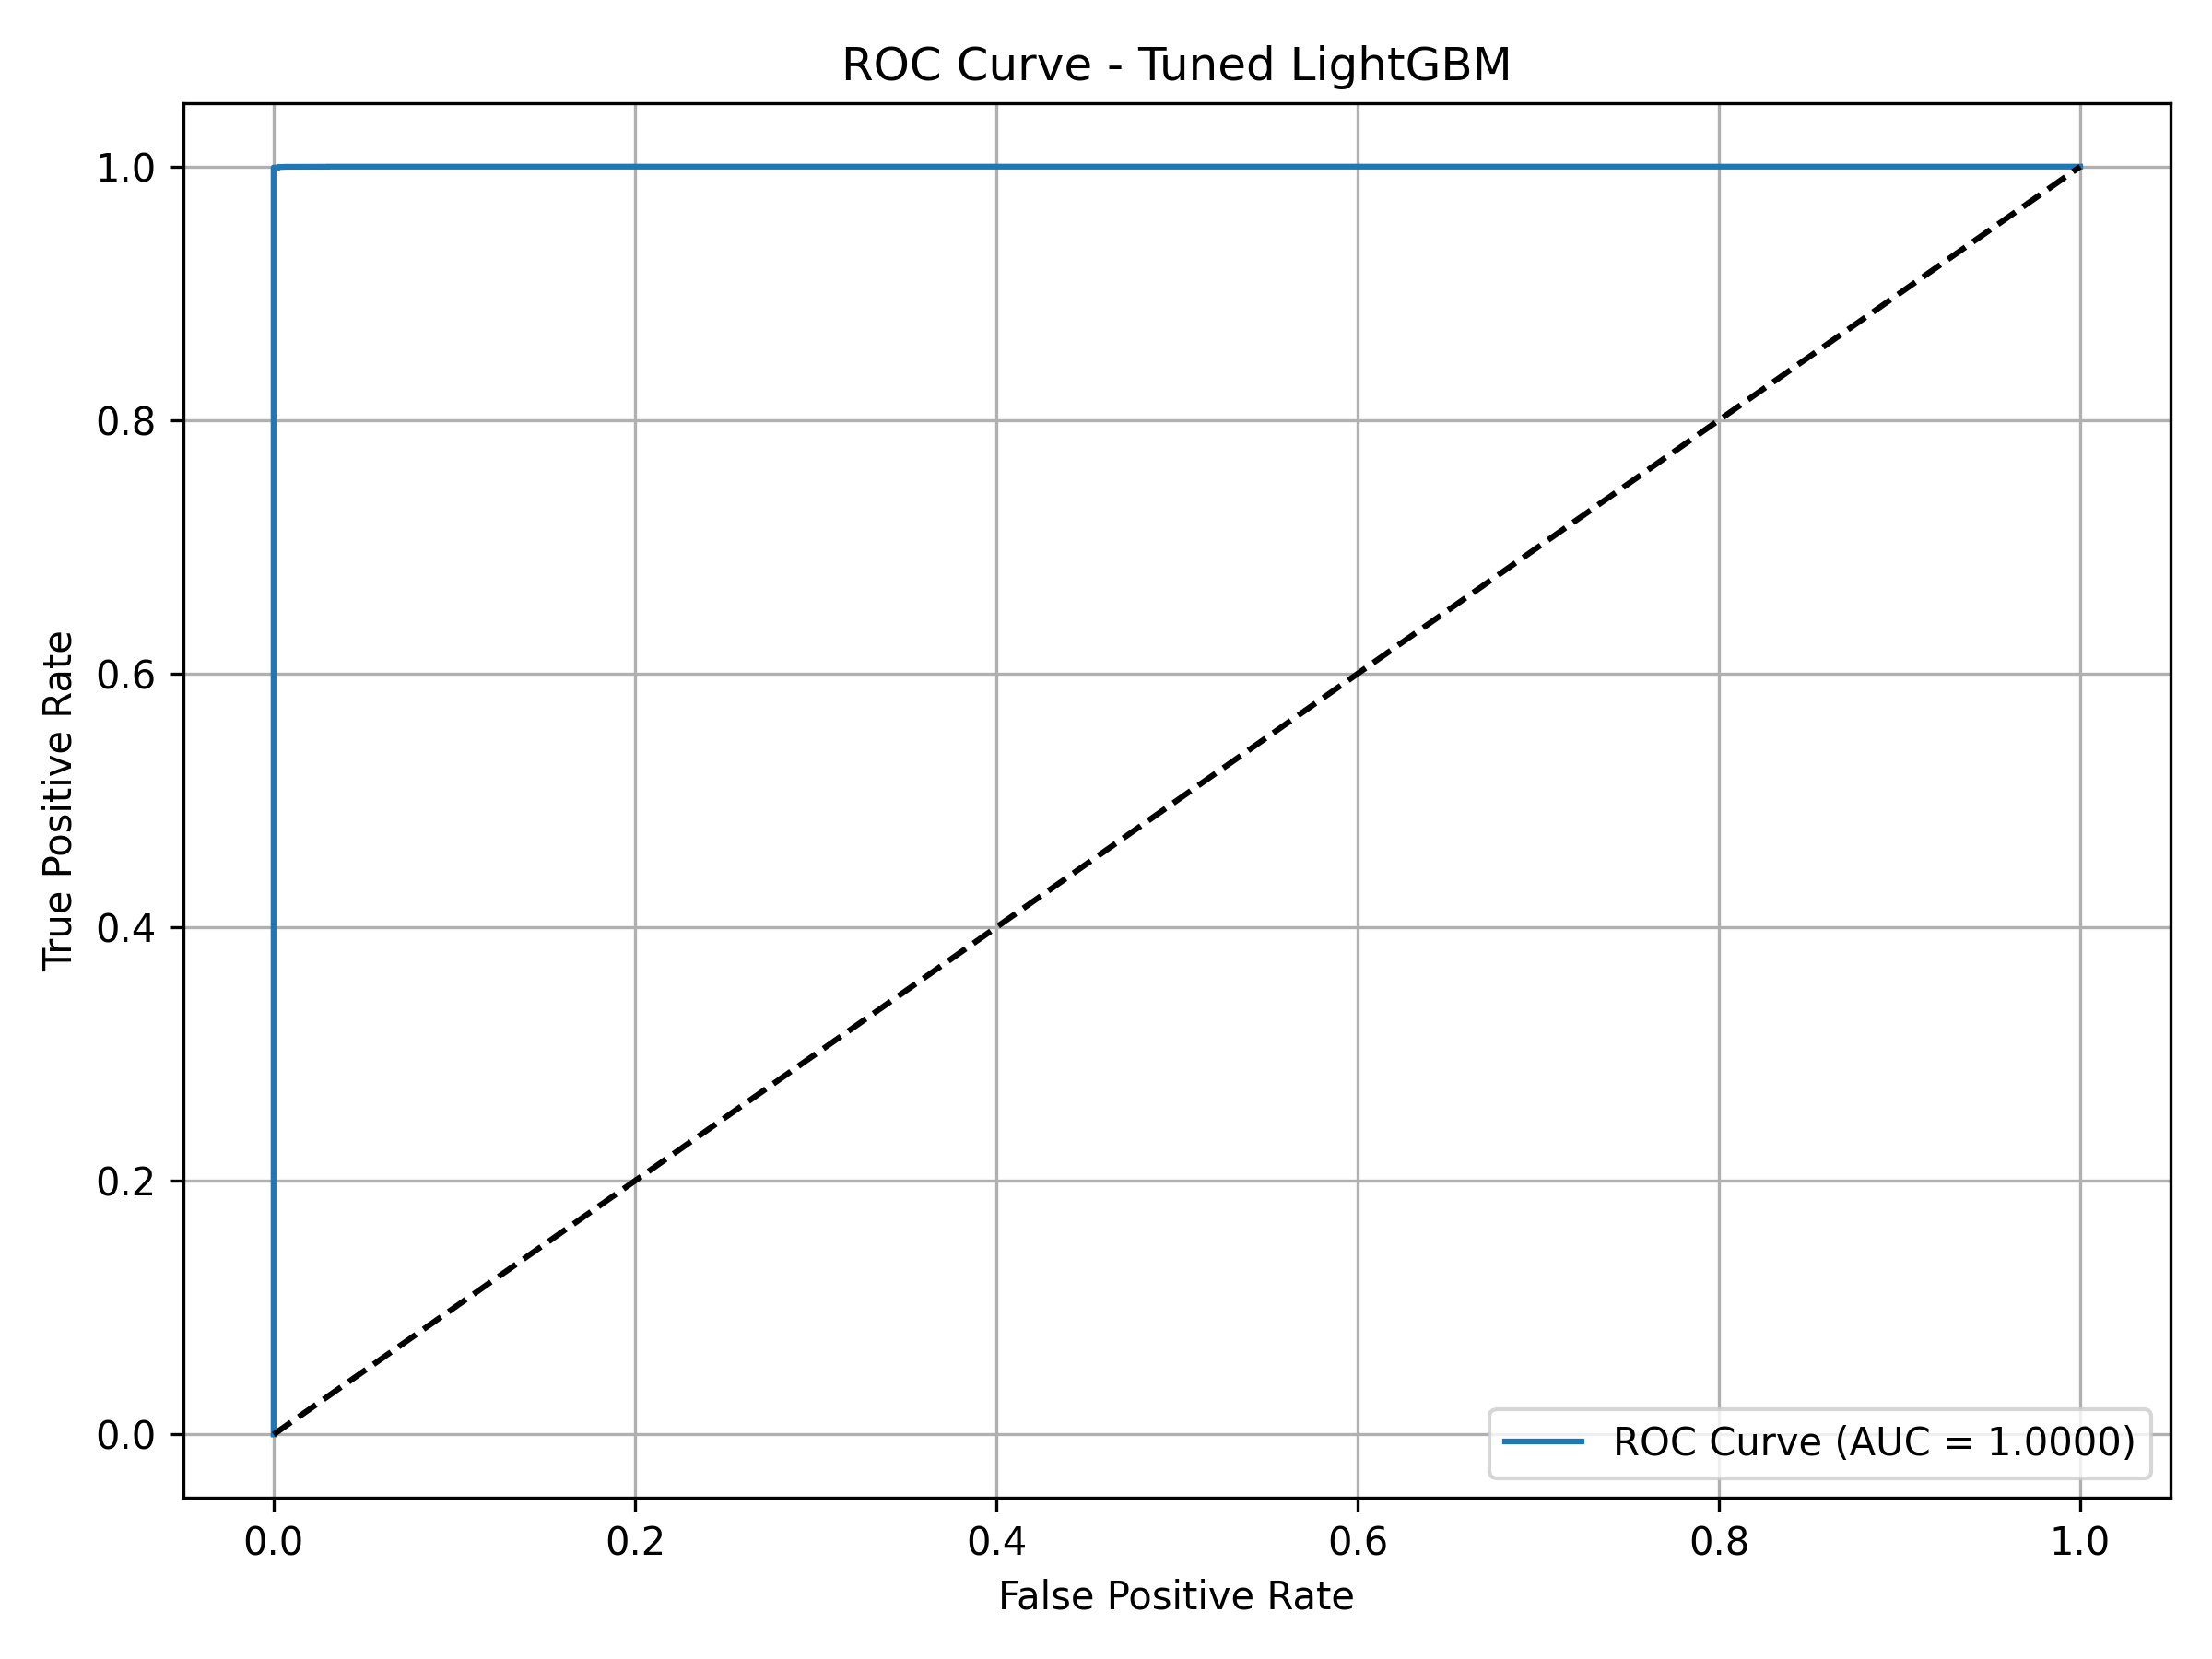

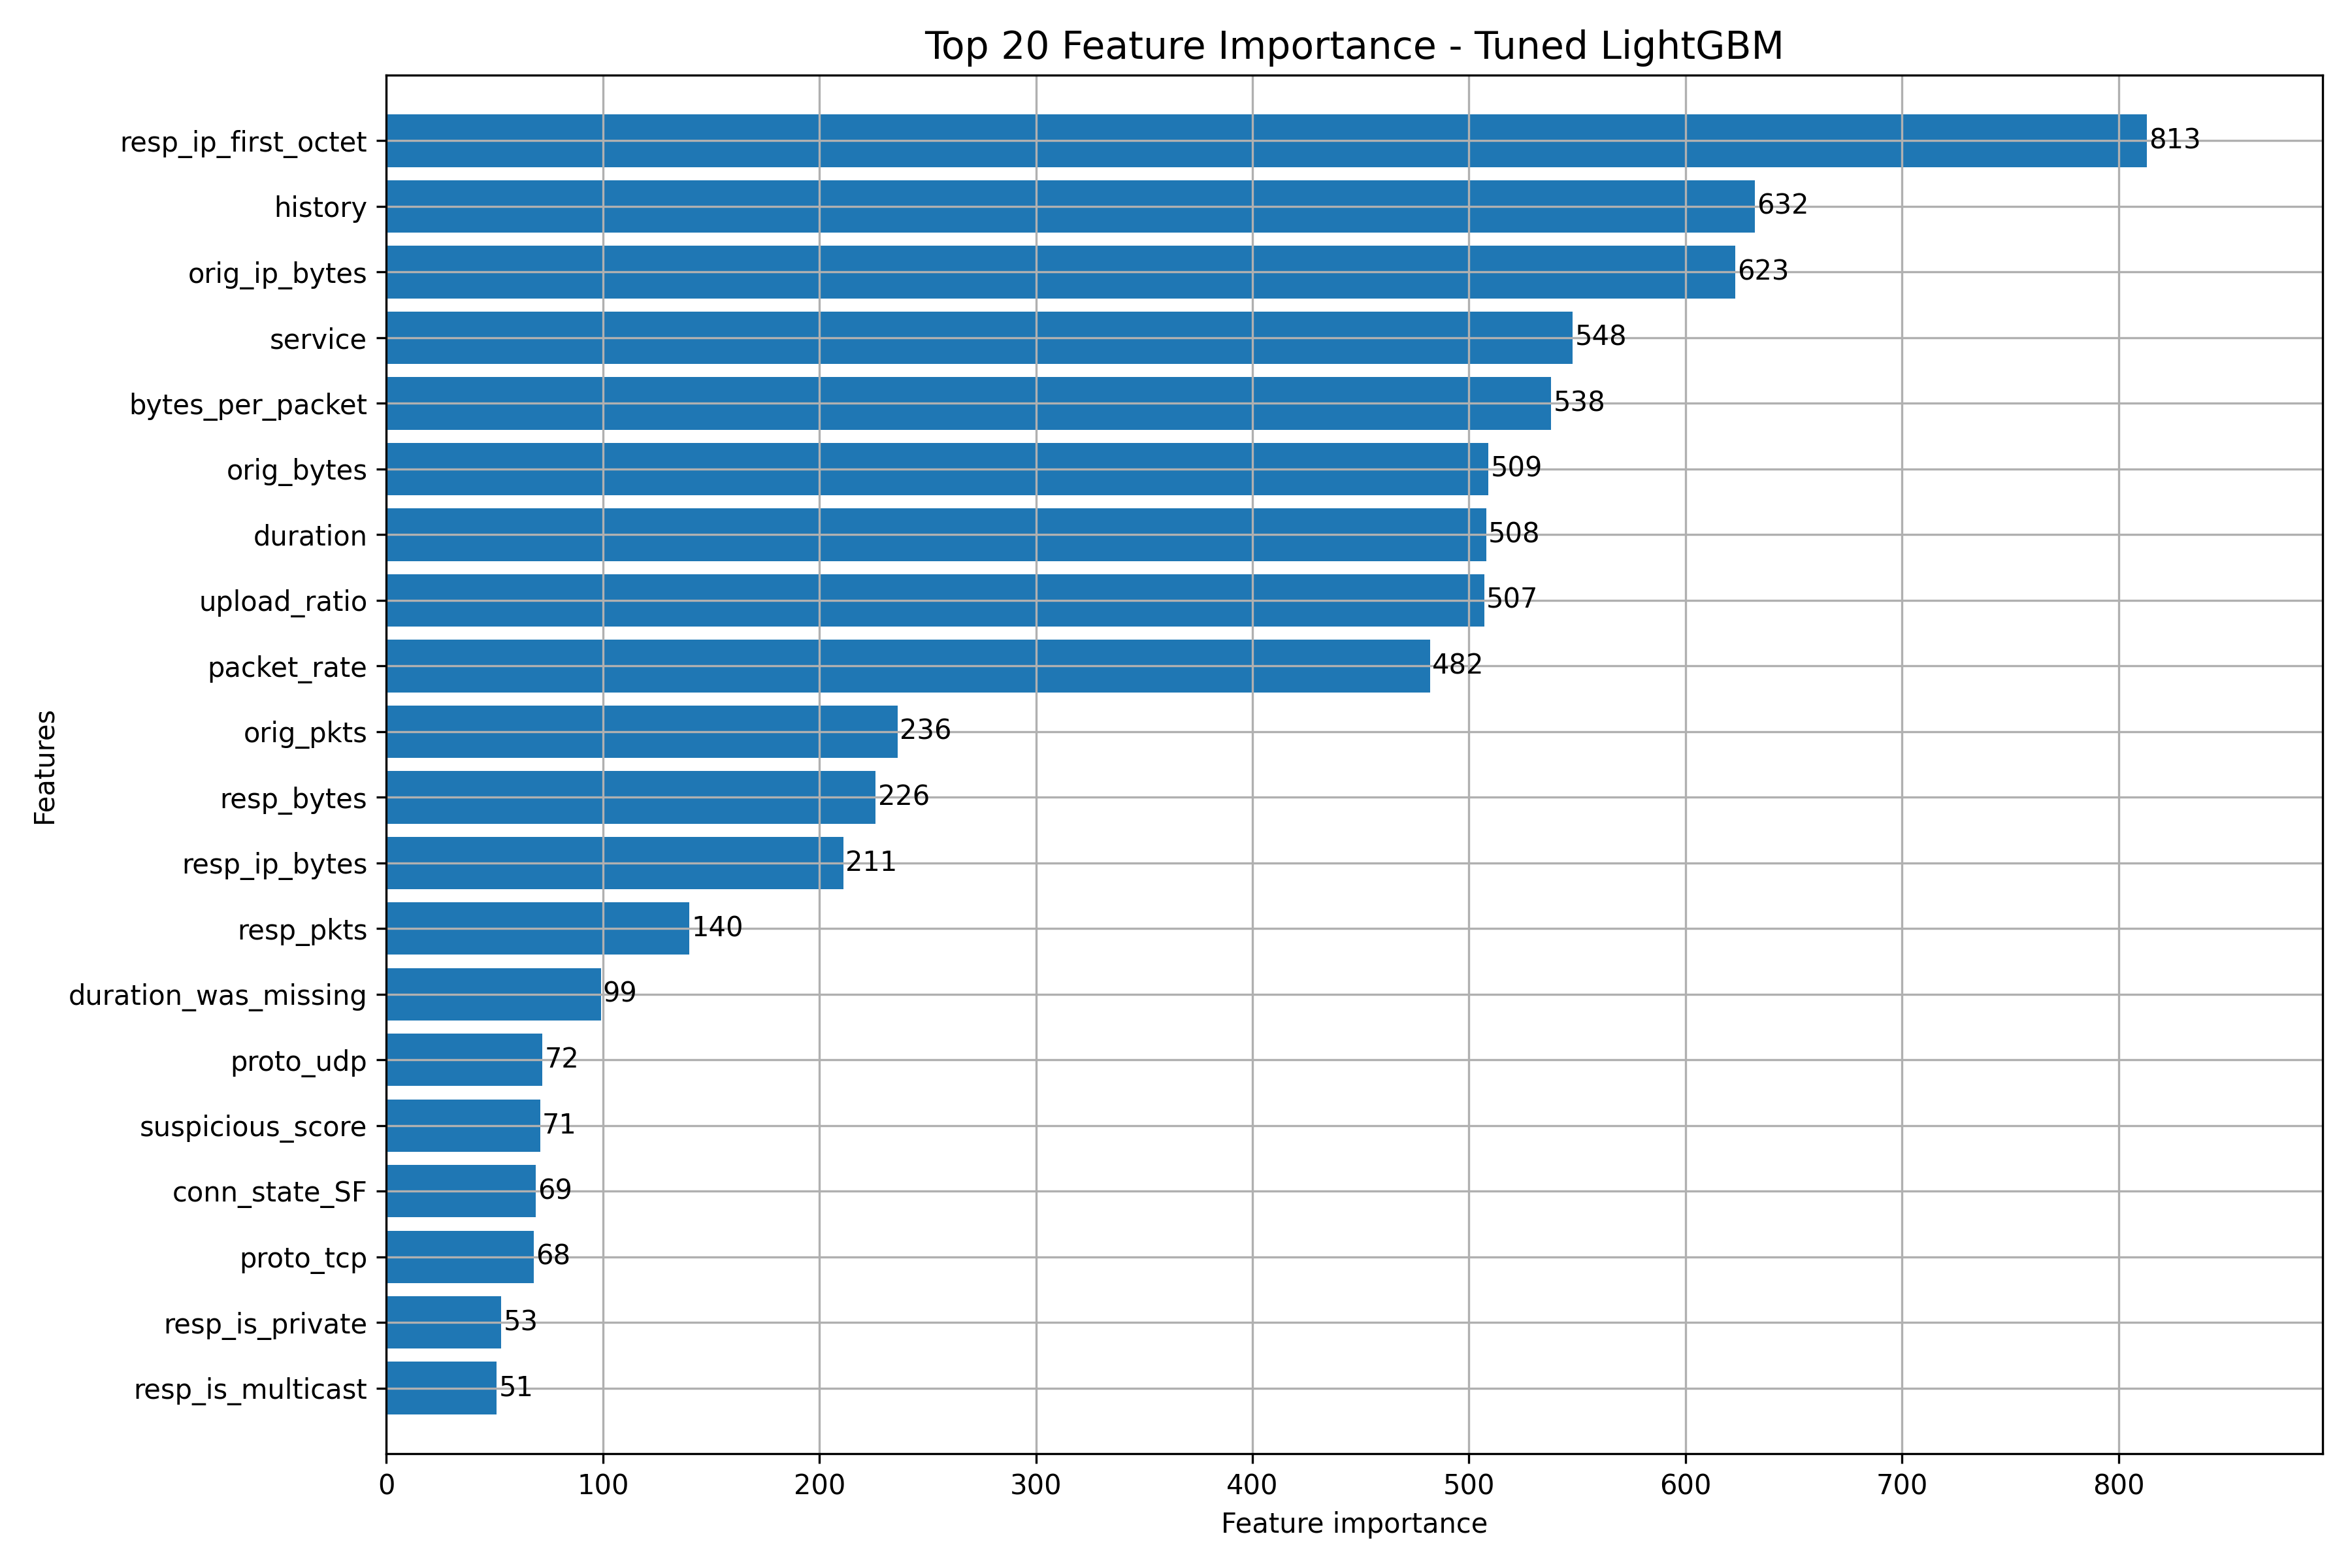


--- Evaluating: Baseline LightGBM (Logistic Config) ---

ADVANCED MODEL: Tuned LightGBM
Binary Classifier (LightGBM) initialized
  Using Optuna: True
  Using SMOTE: True
✓ Model loaded from models/binary_classifier_logistic.pkl

📊 EVALUATING ADVANCED LightGBM MODEL
✓ Predictions complete (0.02s)

──────────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign       0.27      1.00      0.43       365
   Malicious       1.00      0.93      0.97     14970

    accuracy                           0.94     15335
   macro avg       0.64      0.97      0.70     15335
weighted avg       0.98      0.94      0.95     15335

──────────────────────────────────────────────────────────────────────
CONFUSION MATRIX
──────────────────────────────────────────────────────────────────────
                 Predicted
                 Benign 

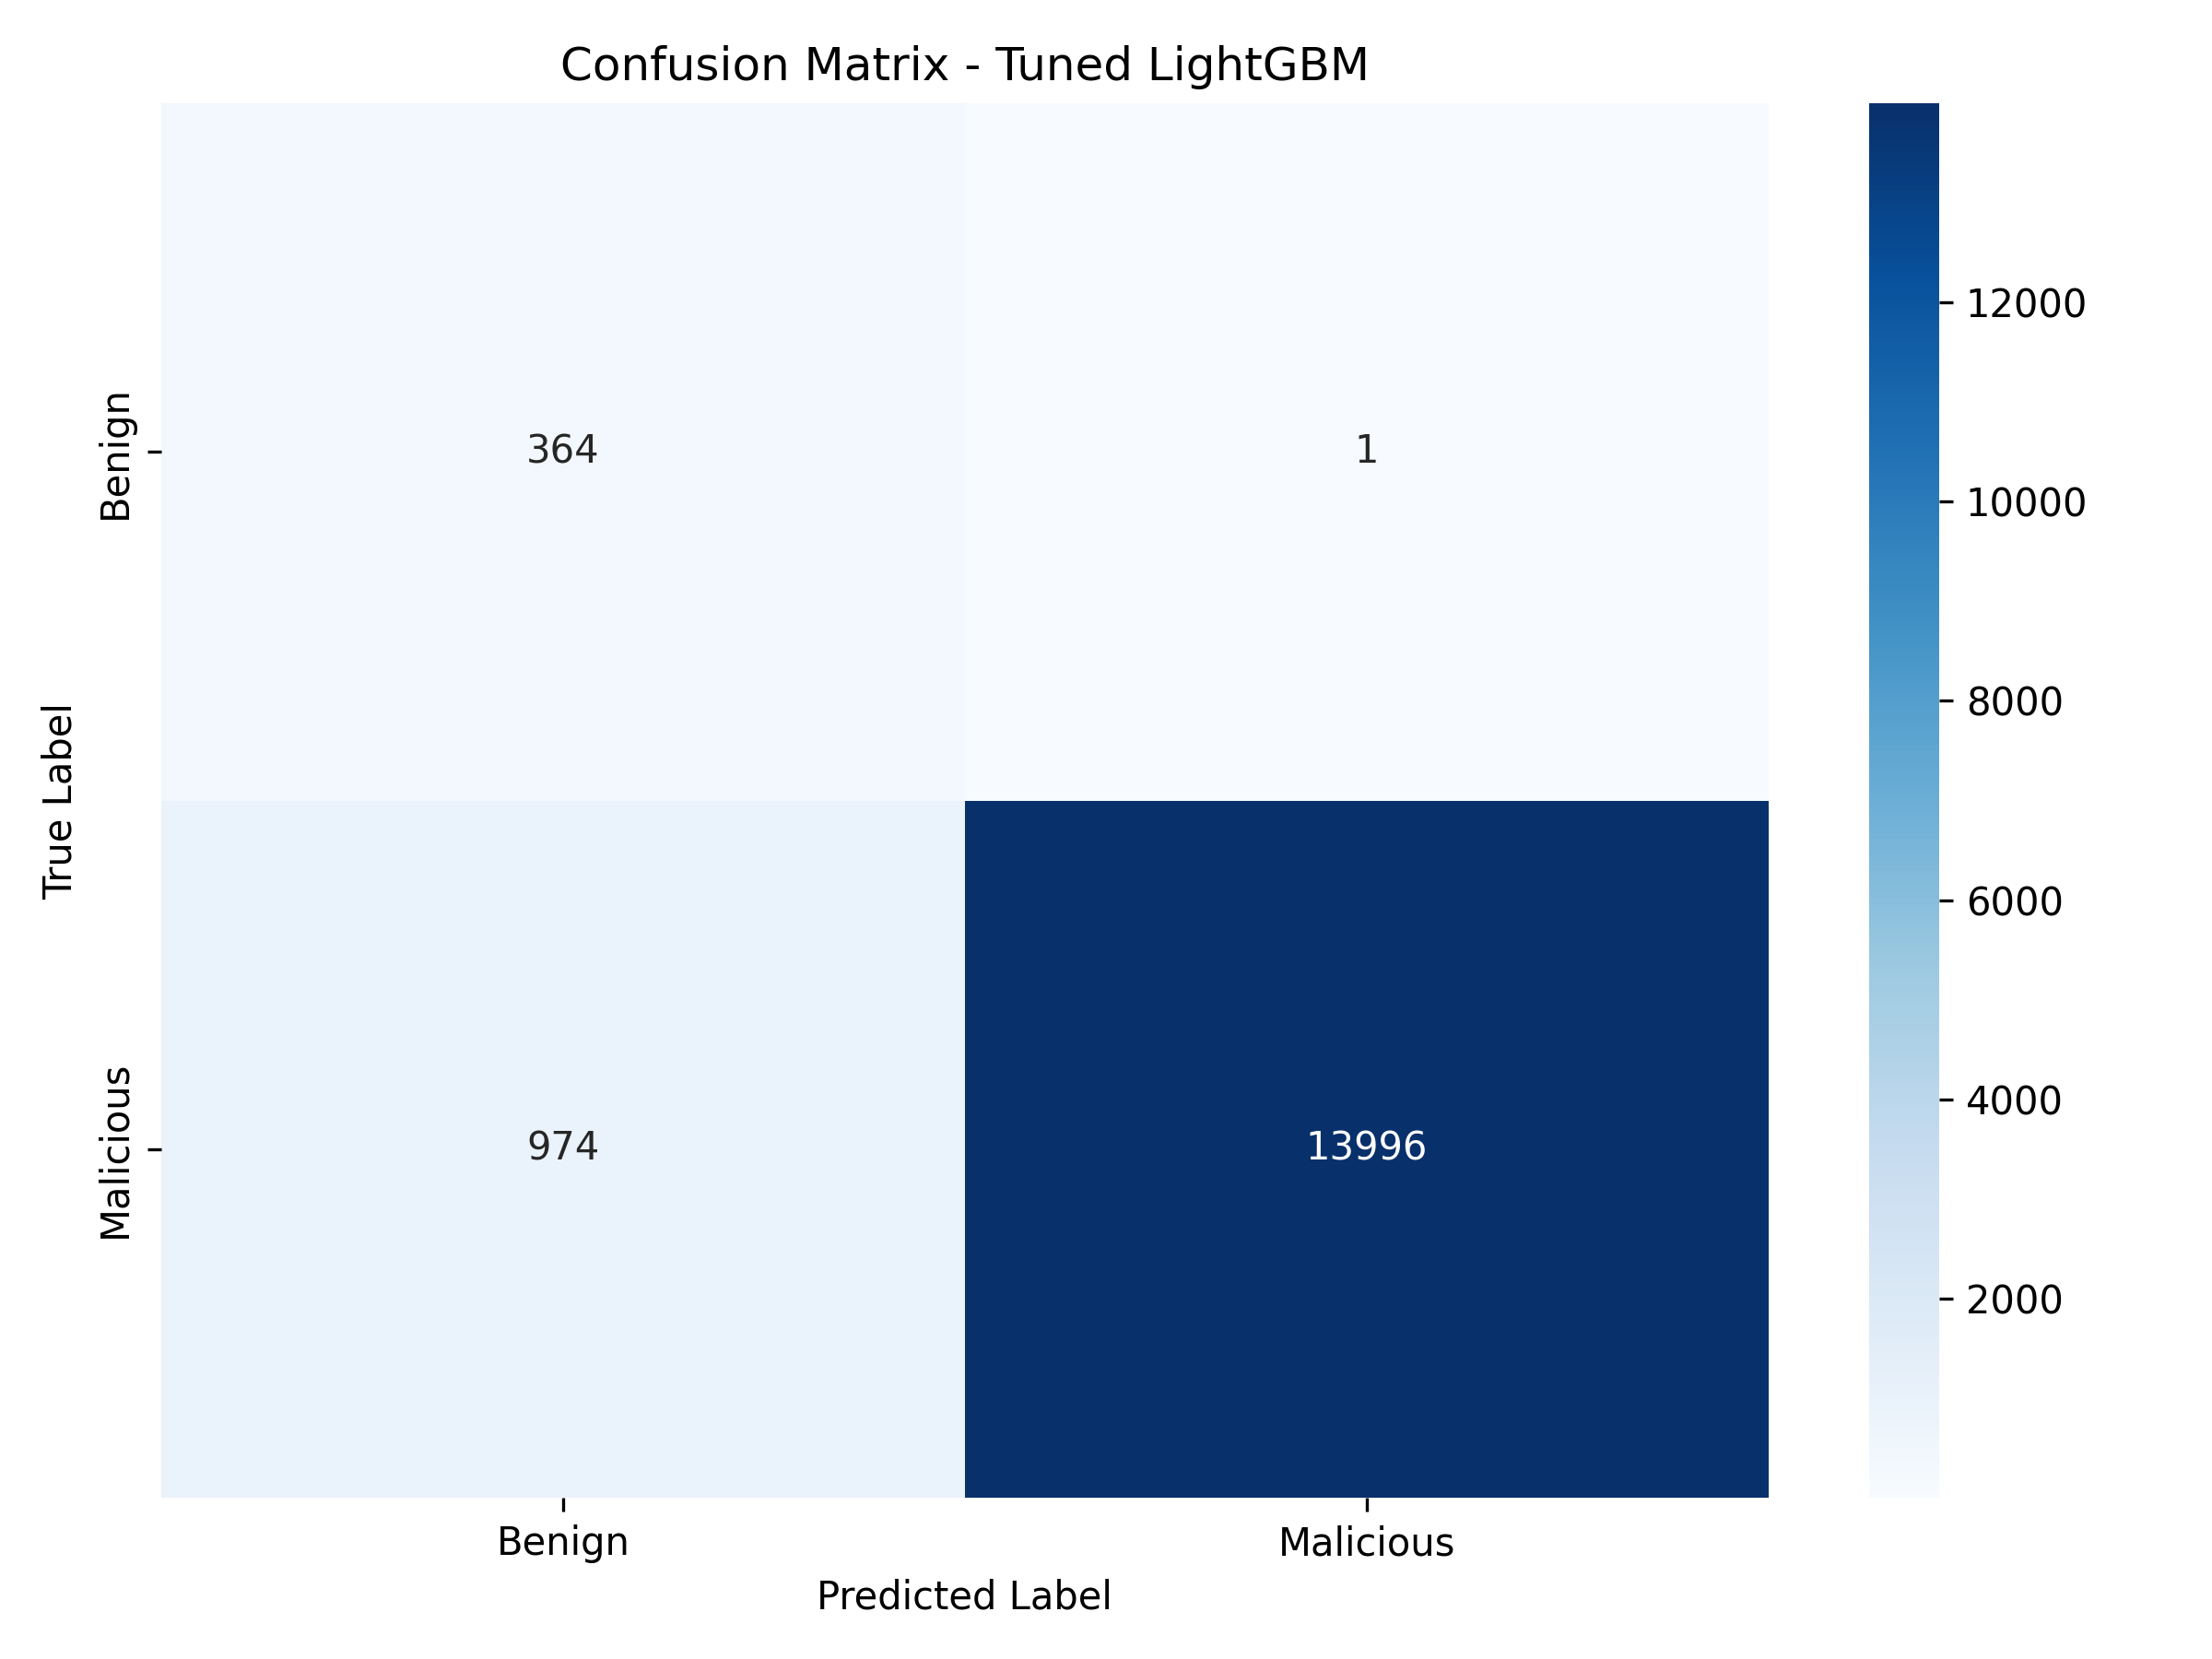

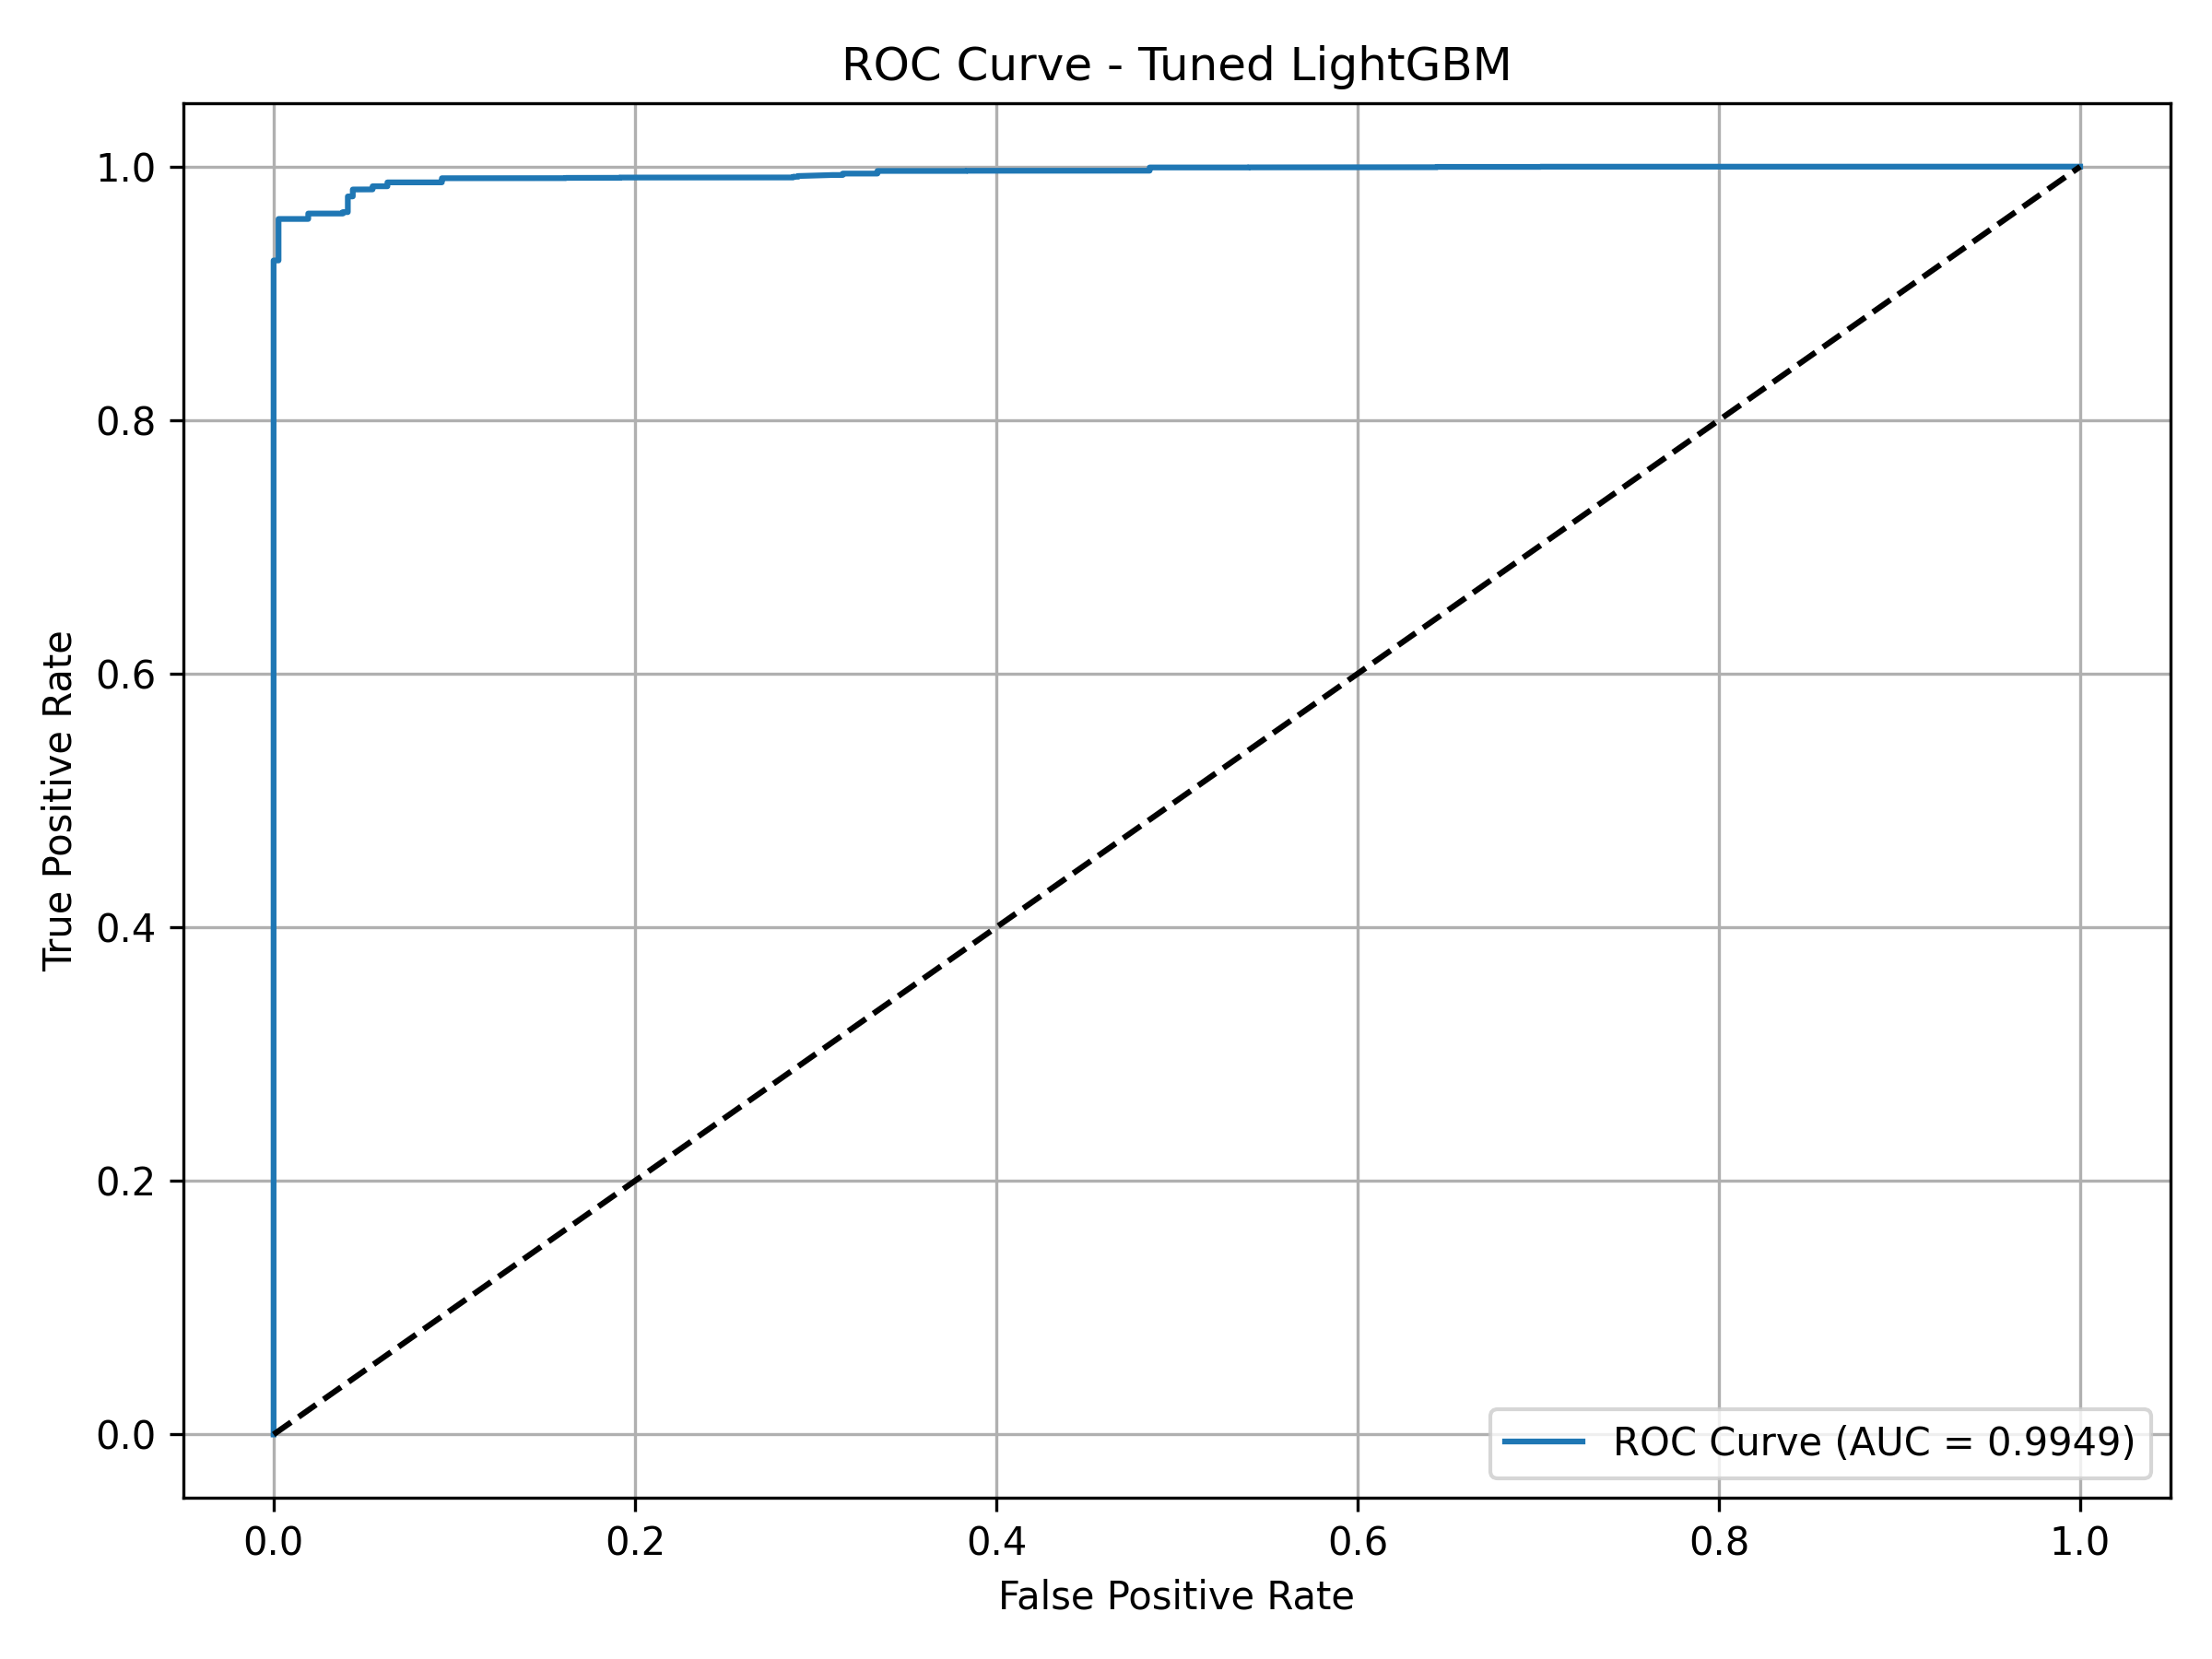

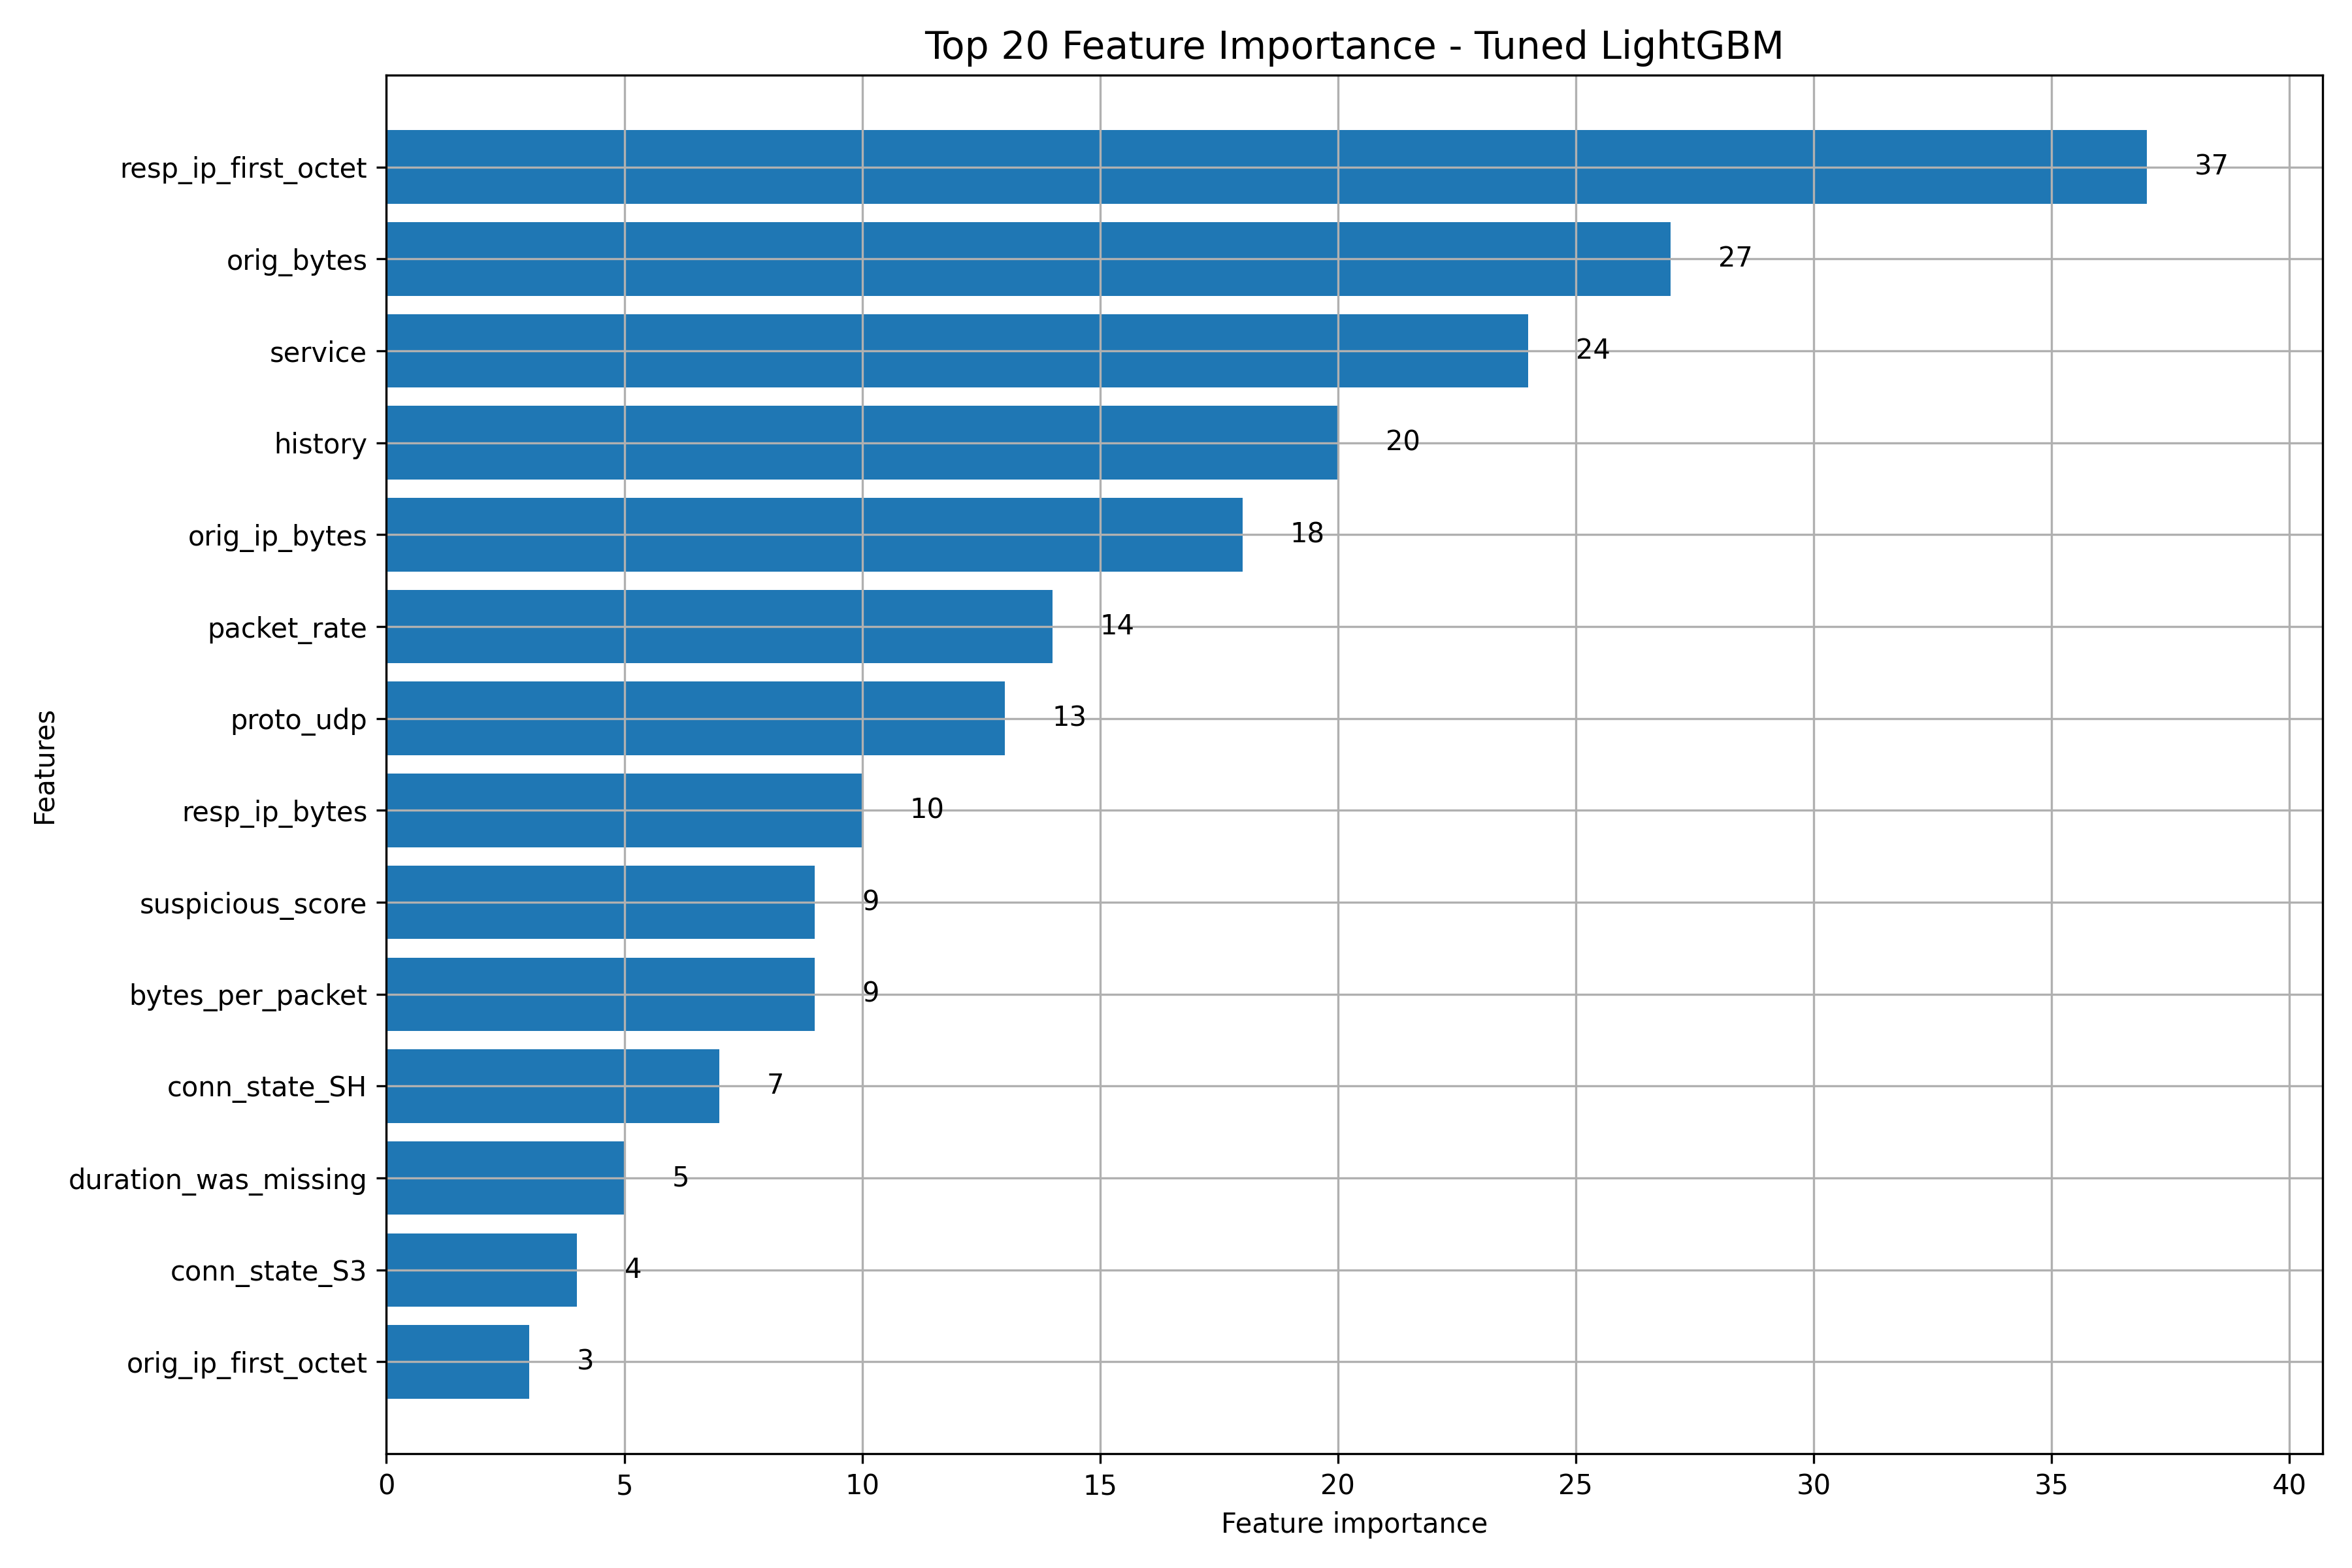

In [2]:
# %%
# ===================================================================
# CELL 2: EVALUATE BINARY CLASSIFIERS (WITH PLOTS DISPLAYED)
# ===================================================================
# Imports needed to display plots in the notebook
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os

print("=" * 70)
print("Evaluating Binary Classification Models")
print("=" * 70)

# 1. Load Data
_, X_test_bin, _, y_test_bin = get_data_for_binary()

# 2. Evaluate Tuned LightGBM Model
print("\n--- Evaluating: Tuned LightGBM ---")
try:
    lgbm_classifier = BinaryClassifier()
    model_path = os.path.join(Config.MODELS_DIR, 'binary_classifier_tuned.pkl')
    model_data = joblib.load(model_path)
    lgbm_classifier.model = model_data['model']
    lgbm_classifier.best_params = model_data['params']
    
    print(f"✓ Model loaded from {model_path}")
    # This prints the report and saves all three plots to the /results directory
    lgbm_results = lgbm_classifier.evaluate(X_test_bin, y_test_bin)

    # --- This new section displays the plots that were just saved ---
    print("\n--- Tuned LightGBM Plots ---")
    cm_path = os.path.join(Config.RESULTS_DIR, 'binary_tuned_confusion_matrix.png')
    roc_path = os.path.join(Config.RESULTS_DIR, 'binary_tuned_roc_curve.png')
    fi_path = os.path.join(Config.RESULTS_DIR, 'binary_tuned_feature_importance.png')

    if os.path.exists(cm_path): display(Image(filename=cm_path))
    if os.path.exists(roc_path): display(Image(filename=roc_path))
    if os.path.exists(fi_path): display(Image(filename=fi_path))

except Exception as e:
    print(f"❌ ERROR evaluating Tuned LightGBM: {e}")

# 3. Evaluate Baseline Logistic Regression Model
if Config.RUN_LOGISTIC_REGRESSION:
    print("\n--- Evaluating: Baseline LightGBM (Logistic Config) ---")
    try:
        lr_classifier = BinaryClassifier()
        model_path = os.path.join(Config.MODELS_DIR, 'binary_classifier_logistic.pkl')
        model_data = joblib.load(model_path)
        lr_classifier.model = model_data['model'] 
        
        print(f"✓ Model loaded from {model_path}")
        # This will save the baseline's plots, OVERWRITING the files from the tuned model above
        lr_results = lr_classifier.evaluate(X_test_bin, y_test_bin, save_plots=True) 
        
        # --- This section displays the newly overwritten plots ---
        print("\n--- Baseline LightGBM Plots (Note: These files have been overwritten) ---")
        # We use the same file paths because the evaluate method overwrites them
        cm_path = os.path.join(Config.RESULTS_DIR, 'binary_tuned_confusion_matrix.png')
        roc_path = os.path.join(Config.RESULTS_DIR, 'binary_tuned_roc_curve.png')
        fi_path = os.path.join(Config.RESULTS_DIR, 'binary_tuned_feature_importance.png')

        if os.path.exists(cm_path): display(Image(filename=cm_path))
        if os.path.exists(roc_path): display(Image(filename=roc_path))
        if os.path.exists(fi_path): display(Image(filename=fi_path))

    except Exception as e:
        print(f"❌ ERROR evaluating Baseline LightGBM: {e}")


Evaluating Multi-Class Classification Models

🔧 PREPARING MULTI-CLASS CLASSIFICATION DATA

📂 Loading MASTER TRAIN set from: data/master_splits/train_set.parquet
✓ Loaded 61,336 training samples.

📂 Loading MASTER TEST set from: data/master_splits/test_set.parquet
✓ Loaded 15,335 test samples.

🎯 Performing class-aware undersampling on the TRAINING set...
   Original train size: 61,336 rows
   New target train size: 18,400 rows
✓ Subsampling complete. Intermediate training set size: 18,400
   Final check: Removing any classes with only 1 member after sampling...
✓ Final training set size: 18,400
✓ Label encoder saved.

✓ Multiclass data ready.
  - Train samples: 18,400
  - Test samples:  15,335

✓ Loaded 15,335 test samples for multi-class evaluation.

--- Evaluating: Multi-Class XGBoost ---
Multi-Class XGBoost initialized
✓ Model loaded from models/multiclass_xgboost.pkl
Evaluating XGBoost...

--- XGBoost Confusion Matrix Plot ---


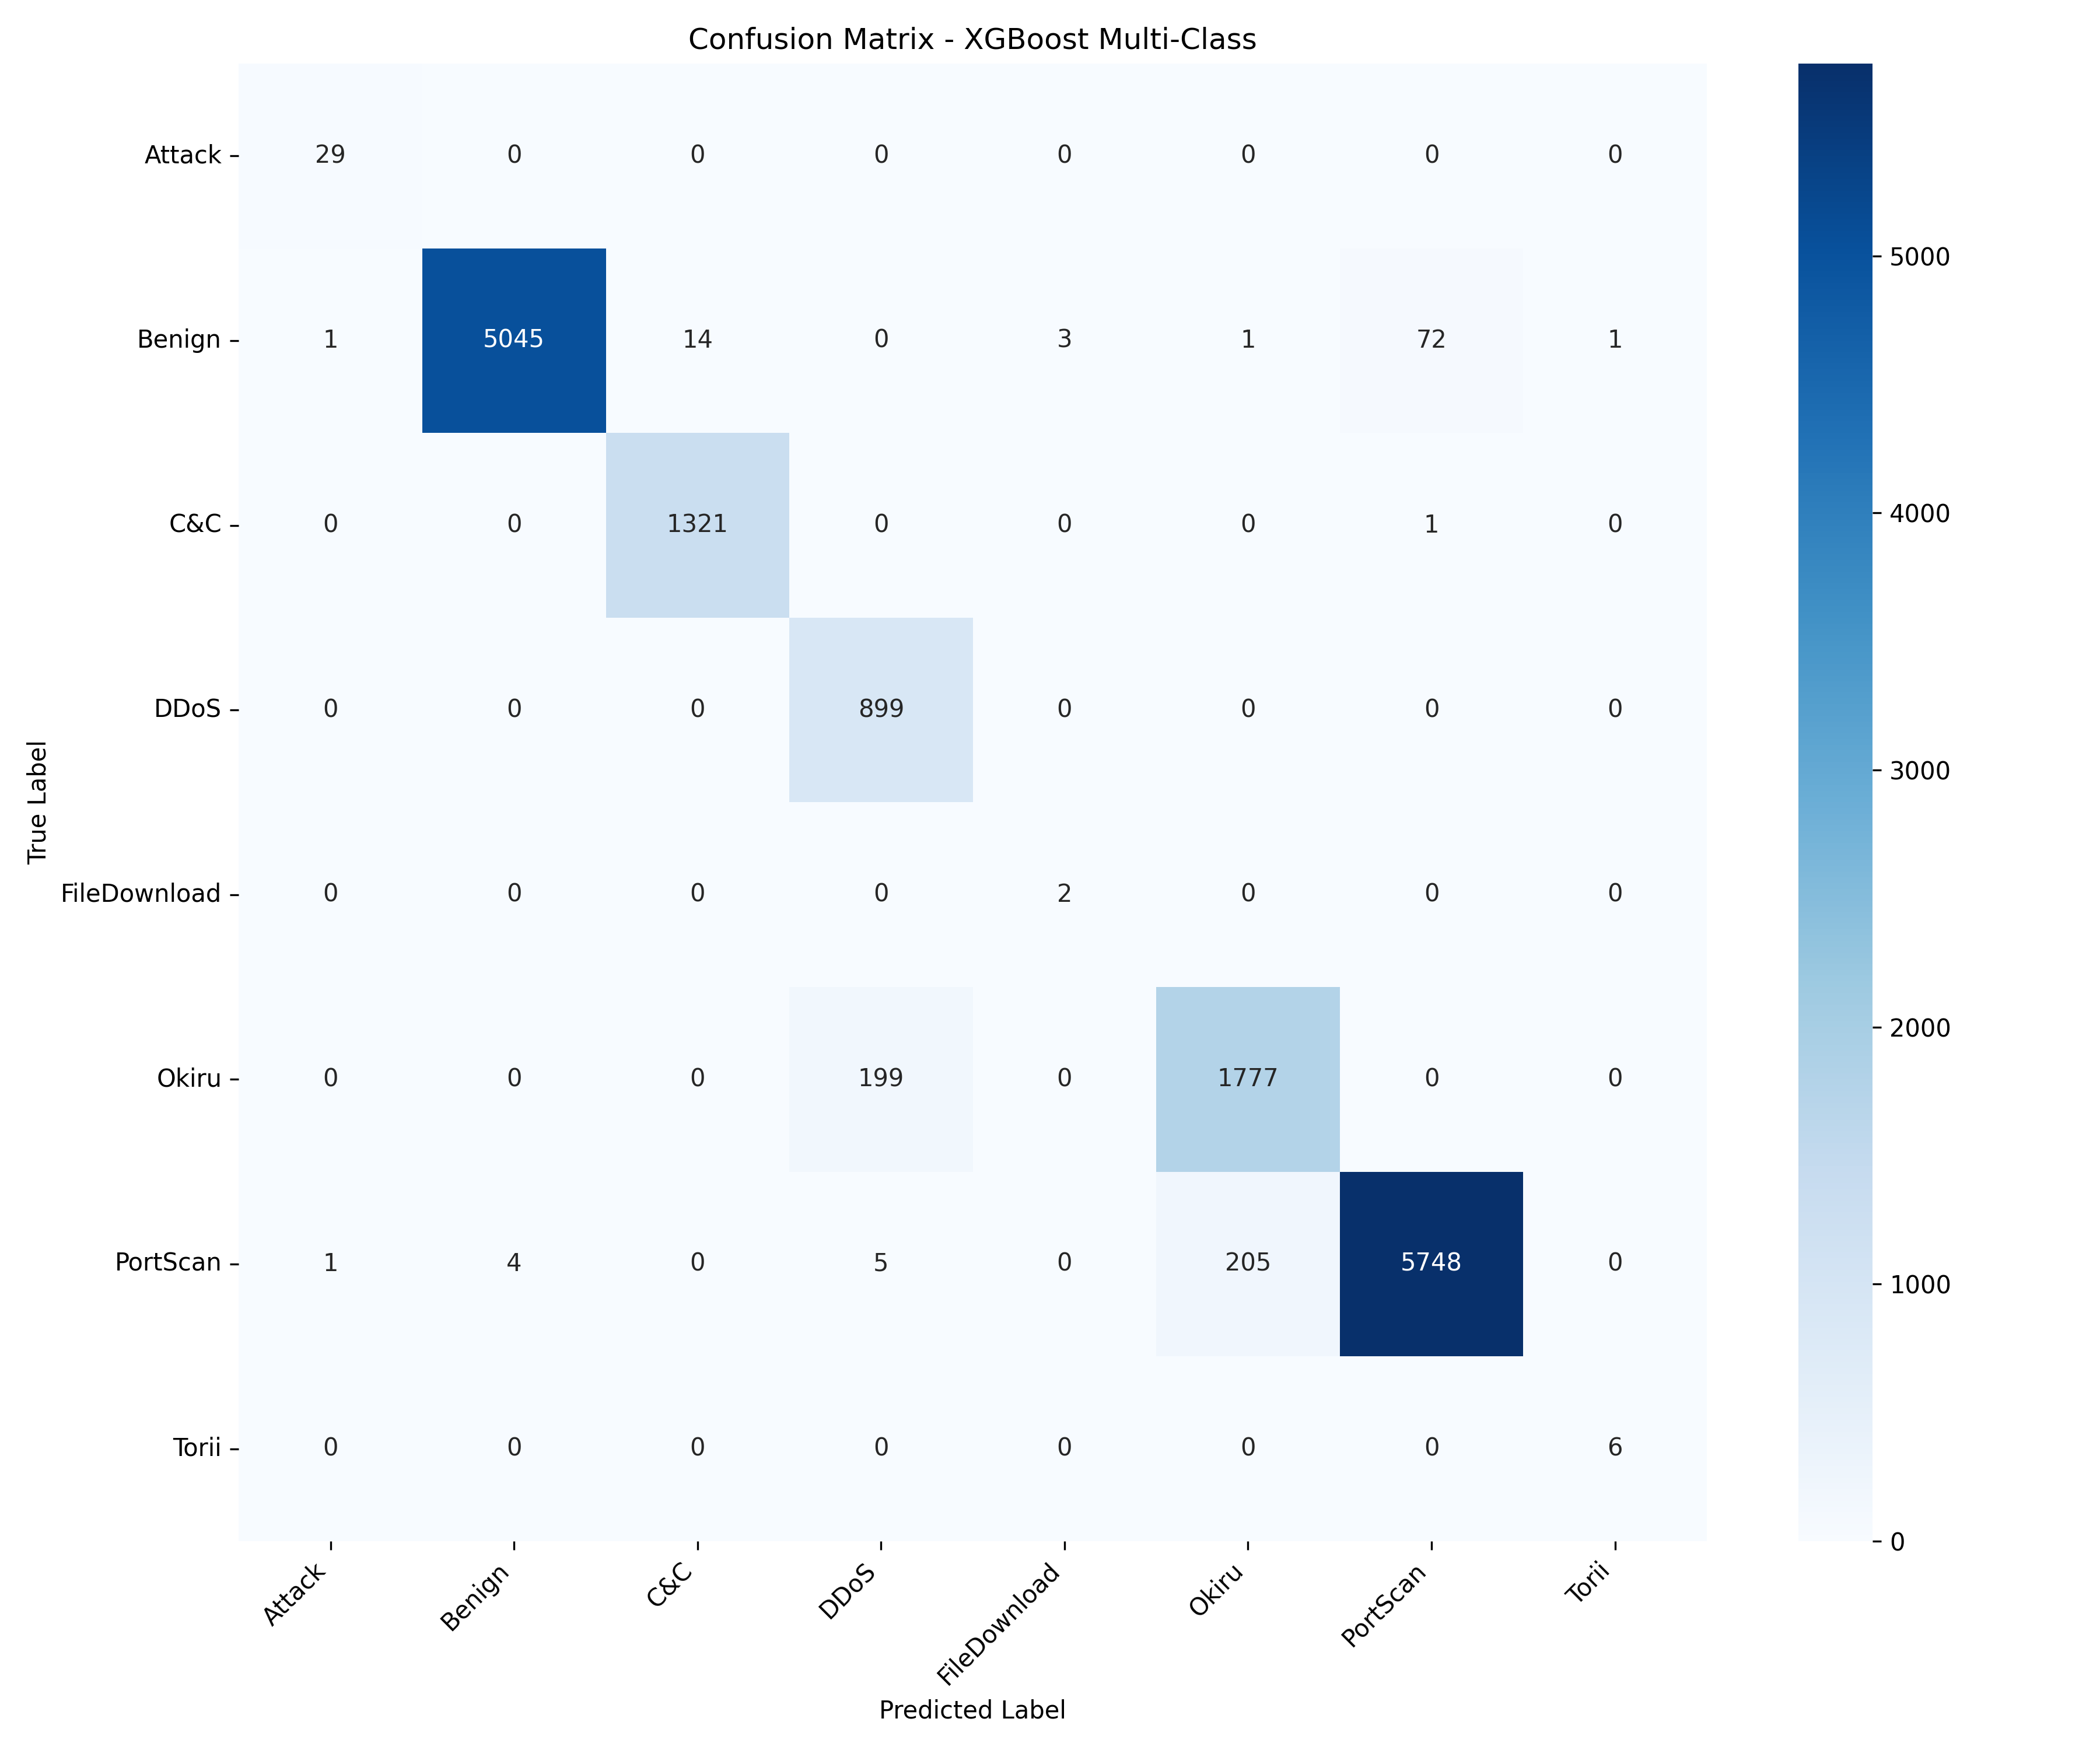


--- Evaluating: Multi-Class Neural Network ---
Multi-Class Neural Net initialized on mps
💾 Reading architecture from checkpoint...

🏗️  Building model with architecture: [256, 256]
✅ Model state loaded successfully into matching architecture.

✓ Notebook is now evaluating model from: models/multiclass_nn.pth

📊 EVALUATING NEURAL NETWORK MULTI-CLASS
              precision    recall  f1-score   support

      Attack       0.57      1.00      0.72        29
      Benign       0.98      0.97      0.98      5247
         C&C       0.84      0.98      0.91      1276
        DDoS       0.66      0.91      0.77       930
FileDownload       0.12      1.00      0.22         2
       Okiru       0.78      0.90      0.83      1945
    PortScan       0.96      0.81      0.88      5899
       Torii       0.04      0.57      0.07         7

    accuracy                           0.90     15335
   macro avg       0.62      0.89      0.67     15335
weighted avg       0.92      0.90      0.90     1533

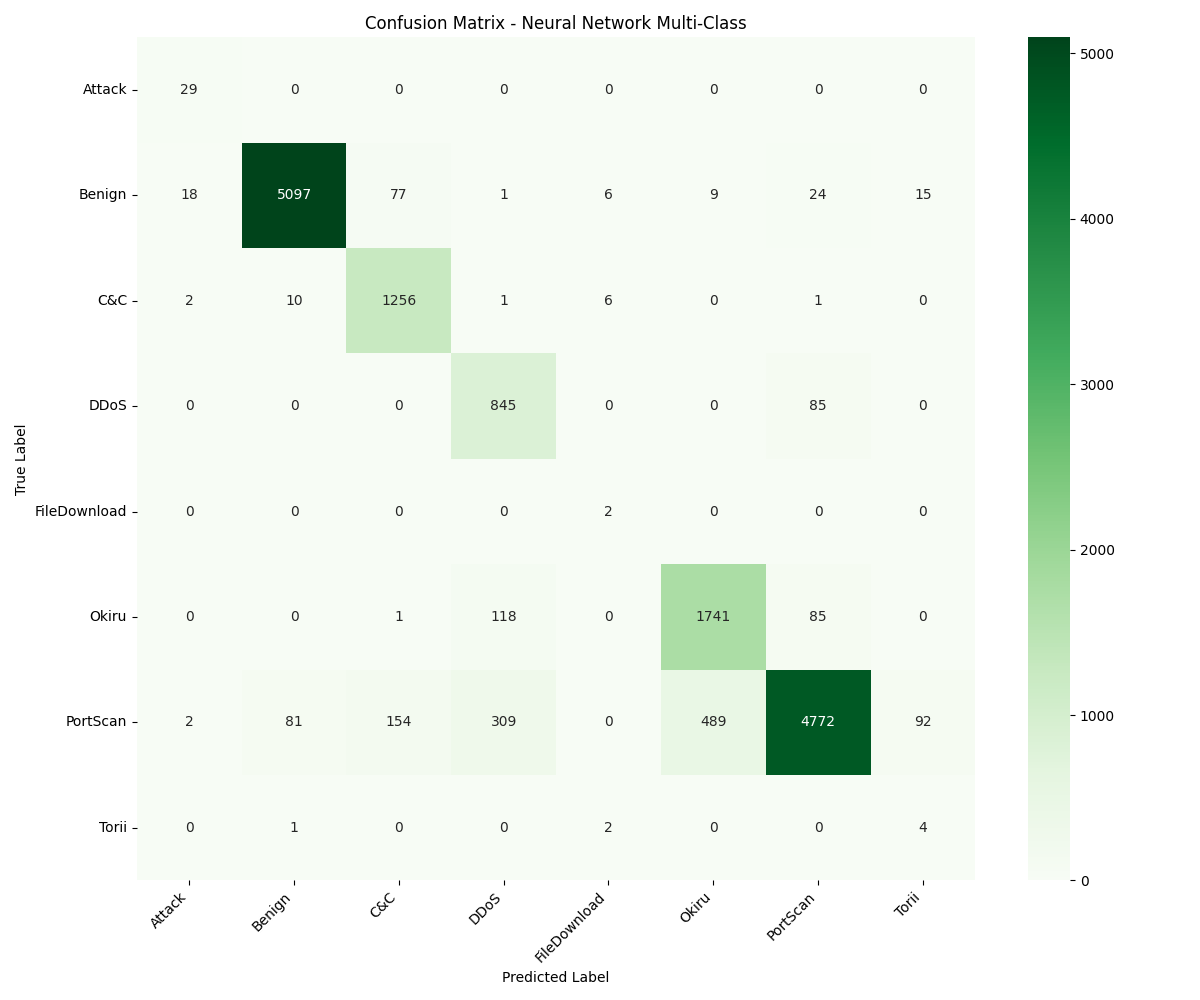

In [3]:
# ===================================================================
# CELL 3: EVALUATE MULTI-CLASS CLASSIFIERS (FINAL WORKING VERSION)
# ===================================================================
from IPython.display import Image, display
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("Evaluating Multi-Class Classification Models")
print("=" * 70)

# 1. Load Data
_, X_test_multi, _, y_test_multi, le_multi = get_data_for_multiclass()
print(f"\n✓ Loaded {len(X_test_multi):,} test samples for multi-class evaluation.")

# 2. Evaluate XGBoost Model
print("\n--- Evaluating: Multi-Class XGBoost ---")
try:
    xgb_model = MultiClassXGBoost()
    model_path = os.path.join(Config.MODELS_DIR, 'multiclass_xgboost.pkl')
    model_data = joblib.load(model_path)
    xgb_model.model = model_data['model']
    xgb_model.best_params = model_data['params']
    
    print(f"✓ Model loaded from {model_path}")
    # This will print the classification report and accuracy, and save the plot
    xgb_results = xgb_model.evaluate(X_test_multi, y_test_multi, le_multi)

    # This new section displays the plot that was just saved
    print("\n--- XGBoost Confusion Matrix Plot ---")
    xgb_cm_path = os.path.join(Config.RESULTS_DIR, 'multiclass_xgboost_confusion_matrix.png')
    if os.path.exists(xgb_cm_path):
        display(Image(filename=xgb_cm_path))
    else:
        print(f"Plot not found at {xgb_cm_path}")

except Exception as e:
    print(f"❌ ERROR evaluating XGBoost: {e}")
    
# 3. Evaluate Neural Network Model
print("\n--- Evaluating: Multi-Class Neural Network ---")
try:
    input_dim = X_test_multi.shape[1]
    # Get the number of classes from the label encoder we just loaded
    num_classes = len(le_multi.classes_)
    
    # ============================================================================
    # THIS IS THE FIX: We must now provide 'num_classes' when initializing the model.
    nn_model = MultiClassNeuralNetModel(input_dim)
    # ============================================================================
    
    # Define the final, official model filename to load.
    model_filename = 'multiclass_nn.pth' 
    
    # This robust function will read the architecture from the file,
    # build the model correctly, and then load the weights.
    nn_model.load_model(model_filename) 
    
    model_path_for_print = os.path.join(Config.MODELS_DIR, model_filename)
    print(f"\n✓ Notebook is now evaluating model from: {model_path_for_print}")
    
    # This will print the classification report and accuracy, and save the plot
    nn_results = nn_model.evaluate(X_test_multi.values, y_test_multi, le_multi)

    # This new section displays the plot that was just saved
    print("\n--- Neural Network Confusion Matrix Plot ---")
    nn_cm_path = os.path.join(Config.RESULTS_DIR, 'multiclass_nn_confusion_matrix.png')
    if os.path.exists(nn_cm_path):
        display(Image(filename=nn_cm_path))
    else:
        print(f"Plot not found at {nn_cm_path}")

except Exception as e:
    # This will catch FileNotFoundError or any other issue during loading/evaluation.
    print(f"❌ AN ERROR OCCURRED: {e}")


Evaluating Virus Family Classification Model

🔧 PREPARING VIRUS CLASSIFICATION DATA

📂 Loading MASTER TRAIN set from: data/master_splits/train_set.parquet
✓ Loaded 39,999,996 training samples.

📂 Loading MASTER TEST set from: data/master_splits/test_set.parquet
✓ Loaded 10,000,000 test samples.
✓ Label encoder saved.

✓ Virus data ready.
  - Train samples: 39,998,535
  - Test samples:  9,999,635

✓ Loaded 9,999,635 malicious test samples for virus family evaluation.
Virus/Malware Family Classifier initialized
  Using Optuna: True
  Using SMOTE: True
✓ Model loaded from models/virus_classifier.pkl

📊 EVALUATING VIRUS CLASSIFIER

⏳ Generating predictions...
✓ Predictions complete (66.66s)
   Throughput: 150020 samples/sec

──────────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

       Gagfyt       1.00      1.00      1.00    

/workspace/malaware_analysis/virus_classifier.py:224: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance[indices], y=[feature_names[i] for i in indices], palette='viridis')


  ✓ Saved feature importance plot

⏱️  Total evaluation time: 72.05s

--- Virus Classifier Plots ---


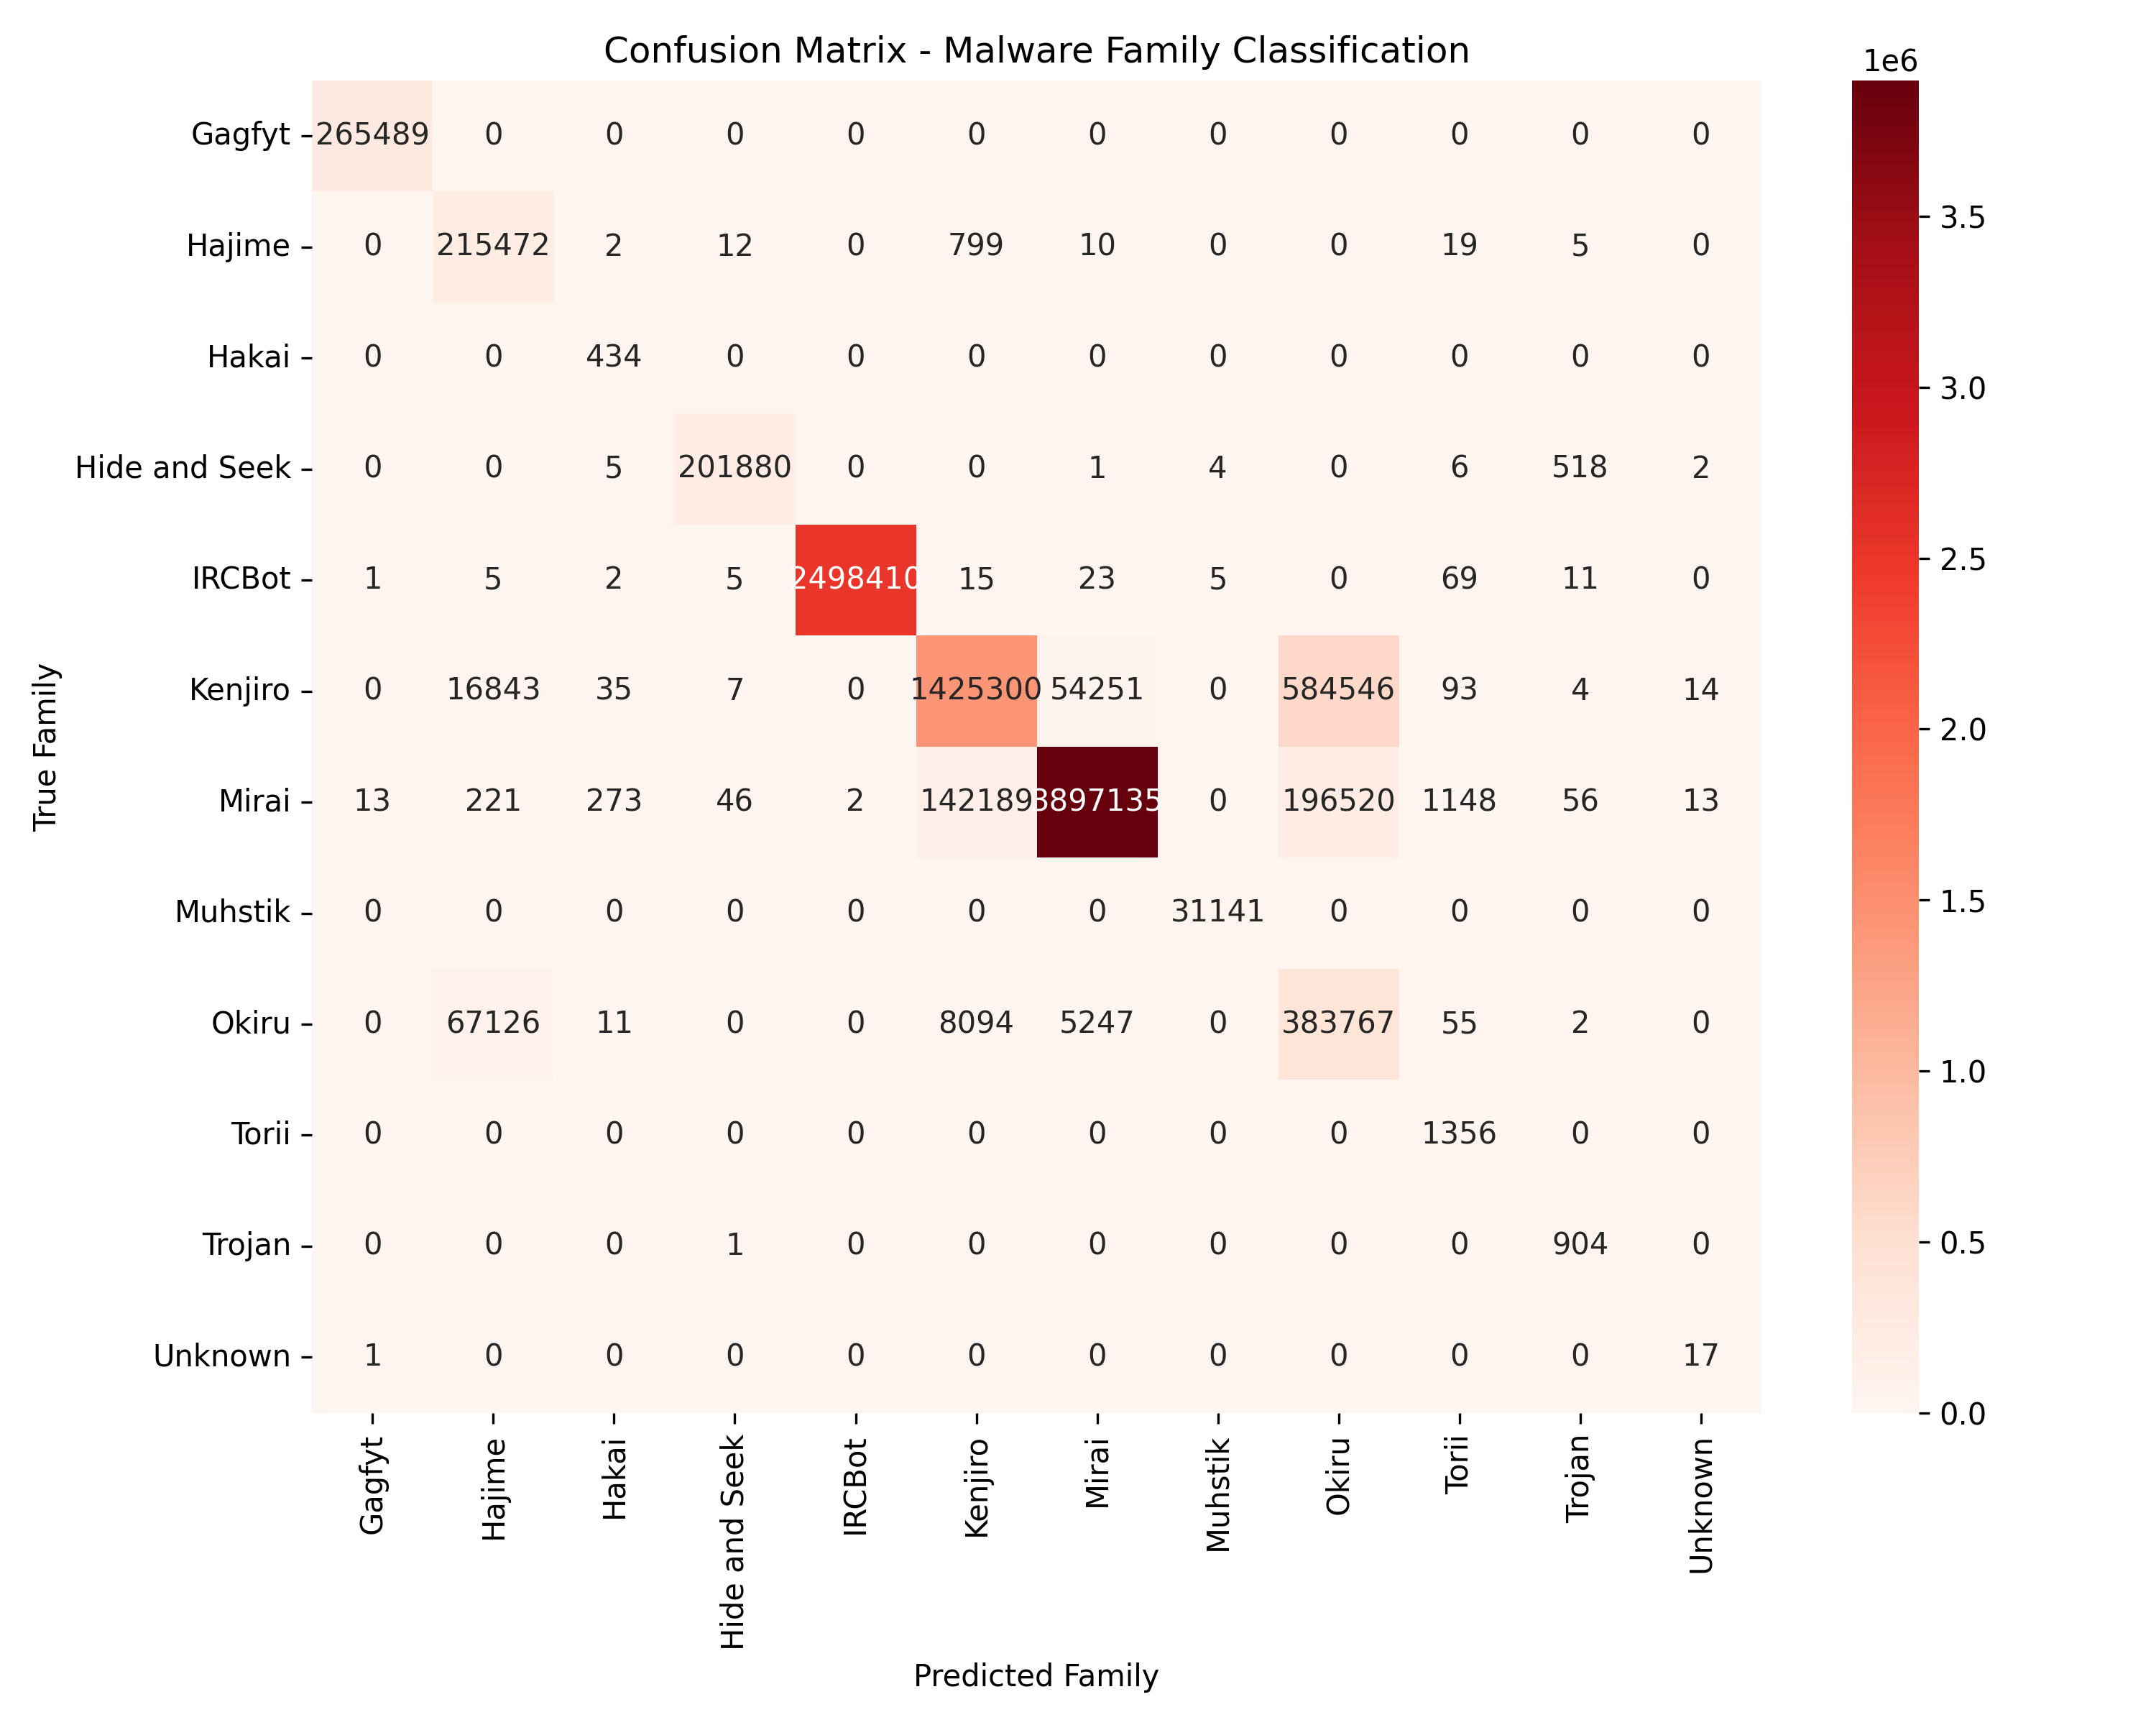

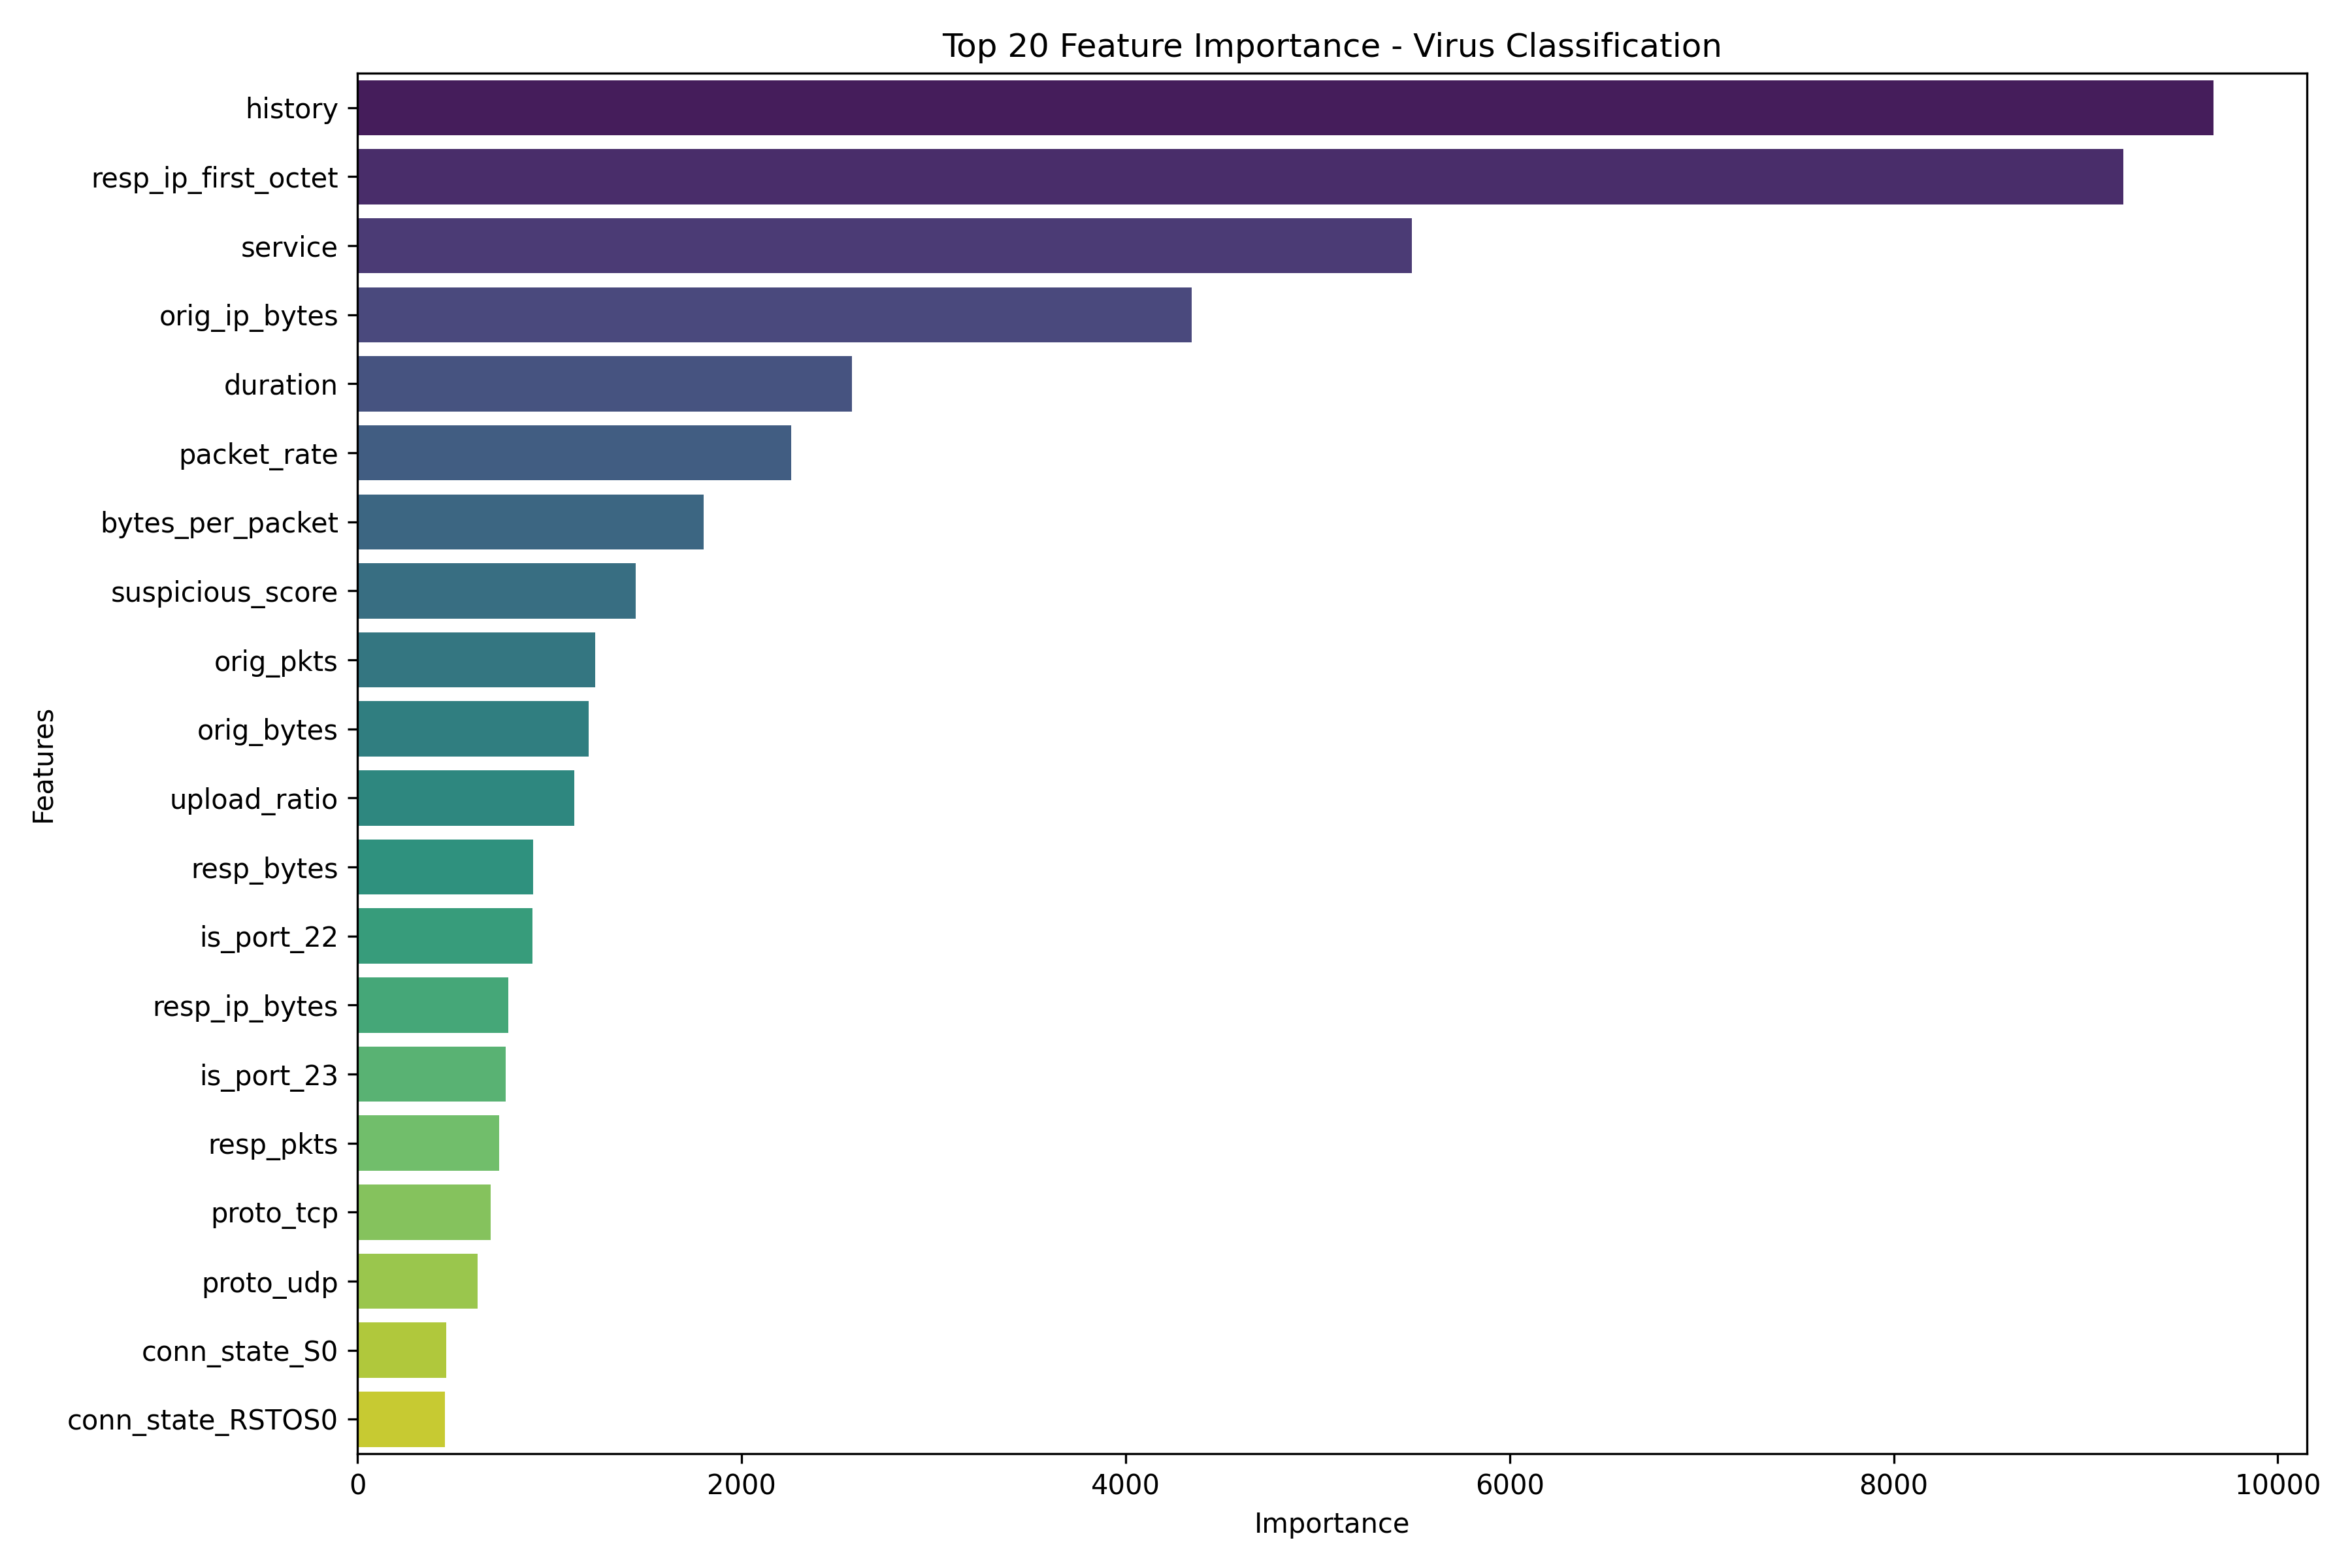


--- Analyzing prediction confidence per family ---

🔬 ANALYZING PREDICTION CONFIDENCE PER FAMILY

📊 Gagfyt:
   Samples: 265,489
   Accuracy: 100.00% (265489/265489)
   Avg Confidence (when correct): 0.9789

📊 Hajime:
   Samples: 216,319
   Accuracy: 99.61% (215472/216319)
   Avg Confidence (when correct): 0.8737

📊 Hakai:
   Samples: 434
   Accuracy: 100.00% (434/434)
   Avg Confidence (when correct): 0.9742

📊 Hide and Seek:
   Samples: 202,416
   Accuracy: 99.74% (201880/202416)
   Avg Confidence (when correct): 0.9759

📊 IRCBot:
   Samples: 2,498,546
   Accuracy: 99.99% (2498410/2498546)
   Avg Confidence (when correct): 0.9782

📊 Kenjiro:
   Samples: 2,081,093
   Accuracy: 68.49% (1425300/2081093)
   Avg Confidence (when correct): 0.8565

📊 Mirai:
   Samples: 4,237,616
   Accuracy: 91.97% (3897135/4237616)
   Avg Confidence (when correct): 0.8961

📊 Muhstik:
   Samples: 31,141
   Accuracy: 100.00% (31141/31141)
   Avg Confidence (when correct): 0.9784

📊 Okiru:
   Samples: 464,302

In [4]:
# ===================================================================
# CELL 4: EVALUATE VIRUS FAMILY CLASSIFIER (WITH PLOTS DISPLAYED)
# ===================================================================
# Imports needed to display plots in the notebook
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os

print("\n" + "=" * 70)
print("Evaluating Virus Family Classification Model")
print("=" * 70)

# 1. Load Data
_, X_test_virus, _, y_test_virus, le_virus = get_data_for_virus()
print(f"\n✓ Loaded {len(X_test_virus):,} malicious test samples for virus family evaluation.")

# 2. Evaluate LightGBM Model
try:
    virus_classifier = VirusClassifier()
    model_path = os.path.join(Config.MODELS_DIR, 'virus_classifier.pkl')
    model_data = joblib.load(model_path)
    virus_classifier.model = model_data['model']
    virus_classifier.best_params = model_data.get('params') # Use .get() for safety
    
    print(f"✓ Model loaded from {model_path}")
    
    # This will print the report, accuracy, and save the plots
    virus_results = virus_classifier.evaluate(X_test_virus, y_test_virus, le_virus)
    
    # --- This new section displays the plots that were just saved ---
    print("\n--- Virus Classifier Plots ---")
    cm_path = os.path.join(Config.RESULTS_DIR, 'virus_confusion_matrix.png')
    fi_path = os.path.join(Config.RESULTS_DIR, 'virus_feature_importance.png')

    if os.path.exists(cm_path):
        display(Image(filename=cm_path))
    if os.path.exists(fi_path):
        display(Image(filename=fi_path))

    # --- Run the confidence analysis as before ---
    print("\n--- Analyzing prediction confidence per family ---")
    virus_classifier.analyze_families(X_test_virus, y_test_virus, le_virus)

except Exception as e:
    print(f"❌ ERROR evaluating Virus Classifier: {e}")


Evaluating Anomaly Detection (Autoencoder) Models

📂 Loading MASTER TEST set from: data/master_splits/test_set.parquet
✓ Loaded 15,335 test samples.
✓ Loaded 365 benign and 14,970 malicious test samples.

--- Evaluating: Standard Autoencoder ---
Autoencoder initialized on mps
💾 Reading architecture from checkpoint...

🏗️  Building model with architecture: [77, 63, 10], latent_dim: 19
✅ Model state loaded successfully into matching architecture.

--- Results on BENIGN Data (Standard AE) ---


Processing batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.91it/s]


  🚨 False Positive Rate: 13.42% (49/365)

--- Results on MALICIOUS Data (Standard AE) ---


Processing batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.59it/s]

  🎯 Detection Rate: 7.09% (1,062/14,970)

--- Standard Autoencoder Training History Plot ---


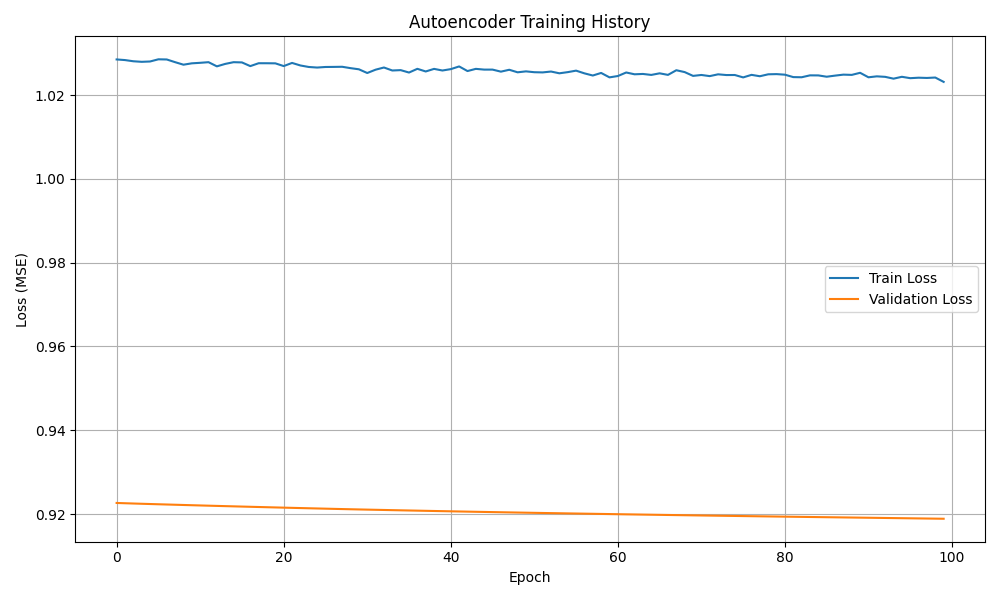


--- Evaluating: Denoising Autoencoder ---
Denoising Autoencoder initialized on mps
✅ Denoising model and scaler loaded successfully.

--- Results on BENIGN Data (Denoising AE) ---


Processing batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 76.69it/s]


  🚨 False Positive Rate: 12.33% (45/365)

--- Results on MALICIOUS Data (Denoising AE) ---


Processing batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 35.16it/s]

  🎯 Detection Rate: 96.36% (14,425/14,970)

--- Denoising Autoencoder Training History Plot ---


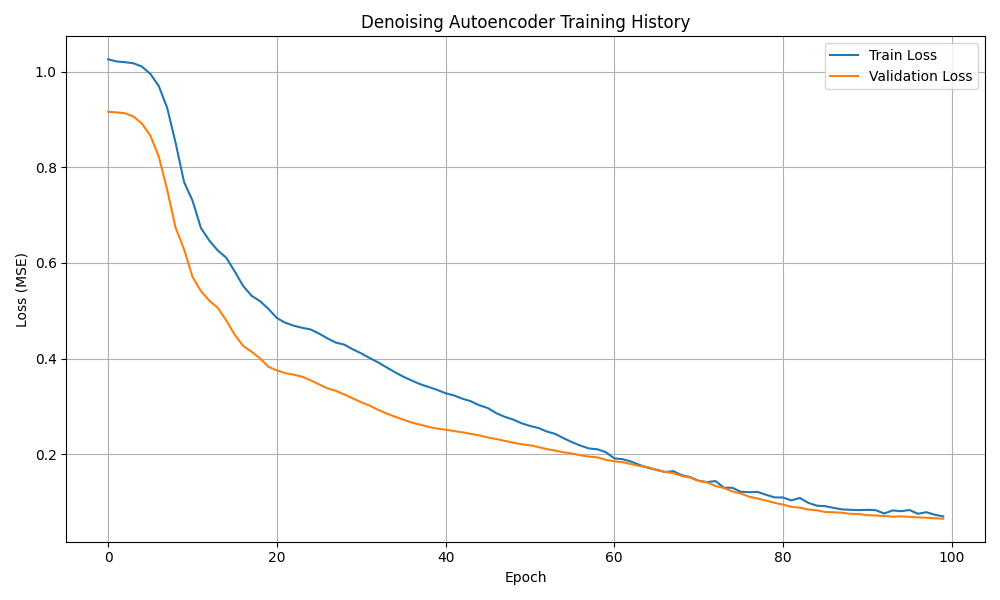

In [4]:
# %%
# ===================================================================
# CELL 5: EVALUATE ANOMALY DETECTION MODELS (WITH PLOTS DISPLAYED)
# ===================================================================
# Imports needed to display plots in the notebook
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os
import joblib # Ensure joblib is imported

print("\n" + "=" * 70)
print("Evaluating Anomaly Detection (Autoencoder) Models")
print("=" * 70)

# 1. Load the full test set
df_test_full = load_master_test_set()
features_used = joblib.load(Config.AUTOENCODER_FEATURE_LIST_PATH)
X_test_benign_ae = df_test_full[df_test_full[Config.TARGET_COL] == 'Benign'][features_used].fillna(0)
X_test_malicious_ae = df_test_full[df_test_full[Config.TARGET_COL] == 'Malicious'][features_used].fillna(0)
print(f"✓ Loaded {len(X_test_benign_ae):,} benign and {len(X_test_malicious_ae):,} malicious test samples.")

# --- Evaluate Standard Autoencoder ---
print("\n--- Evaluating: Standard Autoencoder ---")
try:
    input_dim_ae = len(features_used)
    autoencoder = AutoencoderModel(input_dim_ae)
    
    autoencoder.load_model('autoencoder_final.pth')
    
    X_benign_scaled = autoencoder.scaler.transform(X_test_benign_ae.values)
    X_malicious_scaled = autoencoder.scaler.transform(X_test_malicious_ae.values)
    
    benign_loader = DataLoader(IoTDataset(X_benign_scaled), batch_size=Config.AUTOENCODER_BATCH_SIZE)
    malicious_loader = DataLoader(IoTDataset(X_malicious_scaled), batch_size=Config.AUTOENCODER_BATCH_SIZE)

    print("\n--- Results on BENIGN Data (Standard AE) ---")
    benign_preds, _ = autoencoder.detect_anomalies(benign_loader)
    false_positive_rate = benign_preds.sum() / len(benign_preds) * 100 if len(benign_preds) > 0 else 0
    print(f"  🚨 False Positive Rate: {false_positive_rate:.2f}% ({benign_preds.sum():,}/{len(benign_preds):,})")

    print("\n--- Results on MALICIOUS Data (Standard AE) ---")
    malicious_preds, _ = autoencoder.detect_anomalies(malicious_loader)
    detection_rate = malicious_preds.sum() / len(malicious_preds) * 100 if len(malicious_preds) > 0 else 0
    print(f"  🎯 Detection Rate: {detection_rate:.2f}% ({malicious_preds.sum():,}/{len(malicious_preds):,})")

    # --- This new section displays the training history plot ---
    print("\n--- Standard Autoencoder Training History Plot ---")
    ae_plot_path = os.path.join(Config.RESULTS_DIR, 'autoencoder_training.png')
    if os.path.exists(ae_plot_path):
        display(Image(filename=ae_plot_path))
    else:
        print(f"Plot not found at {ae_plot_path}")

except Exception as e:
     print(f"❌ ERROR evaluating Standard Autoencoder: {e}")

# --- Evaluate Denoising Autoencoder ---
print("\n--- Evaluating: Denoising Autoencoder ---")
try:
    input_dim_dae = len(features_used)
    denoising_ae = DenoisingAutoencoderModel(input_dim_dae)
    
    denoising_ae.load_model('denoising_autoencoder_final.pth')

    X_benign_scaled_dae = denoising_ae.scaler.transform(X_test_benign_ae.values)
    X_malicious_scaled_dae = denoising_ae.scaler.transform(X_test_malicious_ae.values)

    benign_loader_dae = DataLoader(IoTDataset(X_benign_scaled_dae), batch_size=Config.AUTOENCODER_BATCH_SIZE)
    malicious_loader_dae = DataLoader(IoTDataset(X_malicious_scaled_dae), batch_size=Config.AUTOENCODER_BATCH_SIZE)

    print("\n--- Results on BENIGN Data (Denoising AE) ---")
    benign_preds_dae, _ = denoising_ae.detect_anomalies(benign_loader_dae)
    fp_rate_dae = benign_preds_dae.sum() / len(benign_preds_dae) * 100 if len(benign_preds_dae) > 0 else 0
    print(f"  🚨 False Positive Rate: {fp_rate_dae:.2f}% ({benign_preds_dae.sum():,}/{len(benign_preds_dae):,})")

    print("\n--- Results on MALICIOUS Data (Denoising AE) ---")
    malicious_preds_dae, _ = denoising_ae.detect_anomalies(malicious_loader_dae)
    detection_rate_dae = malicious_preds_dae.sum() / len(malicious_preds_dae) * 100 if len(malicious_preds_dae) > 0 else 0
    print(f"  🎯 Detection Rate: {detection_rate_dae:.2f}% ({malicious_preds_dae.sum():,}/{len(malicious_preds_dae):,})")

    # --- This new section displays the training history plot ---
    print("\n--- Denoising Autoencoder Training History Plot ---")
    dae_plot_path = os.path.join(Config.RESULTS_DIR, 'denoising_autoencoder_training.png')
    if os.path.exists(dae_plot_path):
        display(Image(filename=dae_plot_path))
    else:
        print(f"Plot not found at {dae_plot_path}")

except Exception as e:
     print(f"❌ ERROR evaluating Denoising Autoencoder: {e}")


Visualizing K-Means Clustering on Test Data
K-Means Clustering initialized with k=5
✓ Model loaded: kmeans_clustering.pkl
✓ Clustering model loaded from models/kmeans_clustering.pkl

📂 Loading MASTER TEST set from: data/master_splits/test_set.parquet
✓ Loaded 15,335 test samples.

✓ Prepared 14,970 malicious test samples for visualization.

📊 GENERATING CLUSTER VISUALIZATION

⏳ Scaling data for PCA...
⏳ Applying PCA...
✓ PCA complete. Explained variance: 30.5%

⏳ Creating visualization...
✓ Visualization saved to results/clusters_vs_true_labels.png

✓ Clustering visualization complete and saved to the results directory.

--- K-Means Clustering Visualization ---


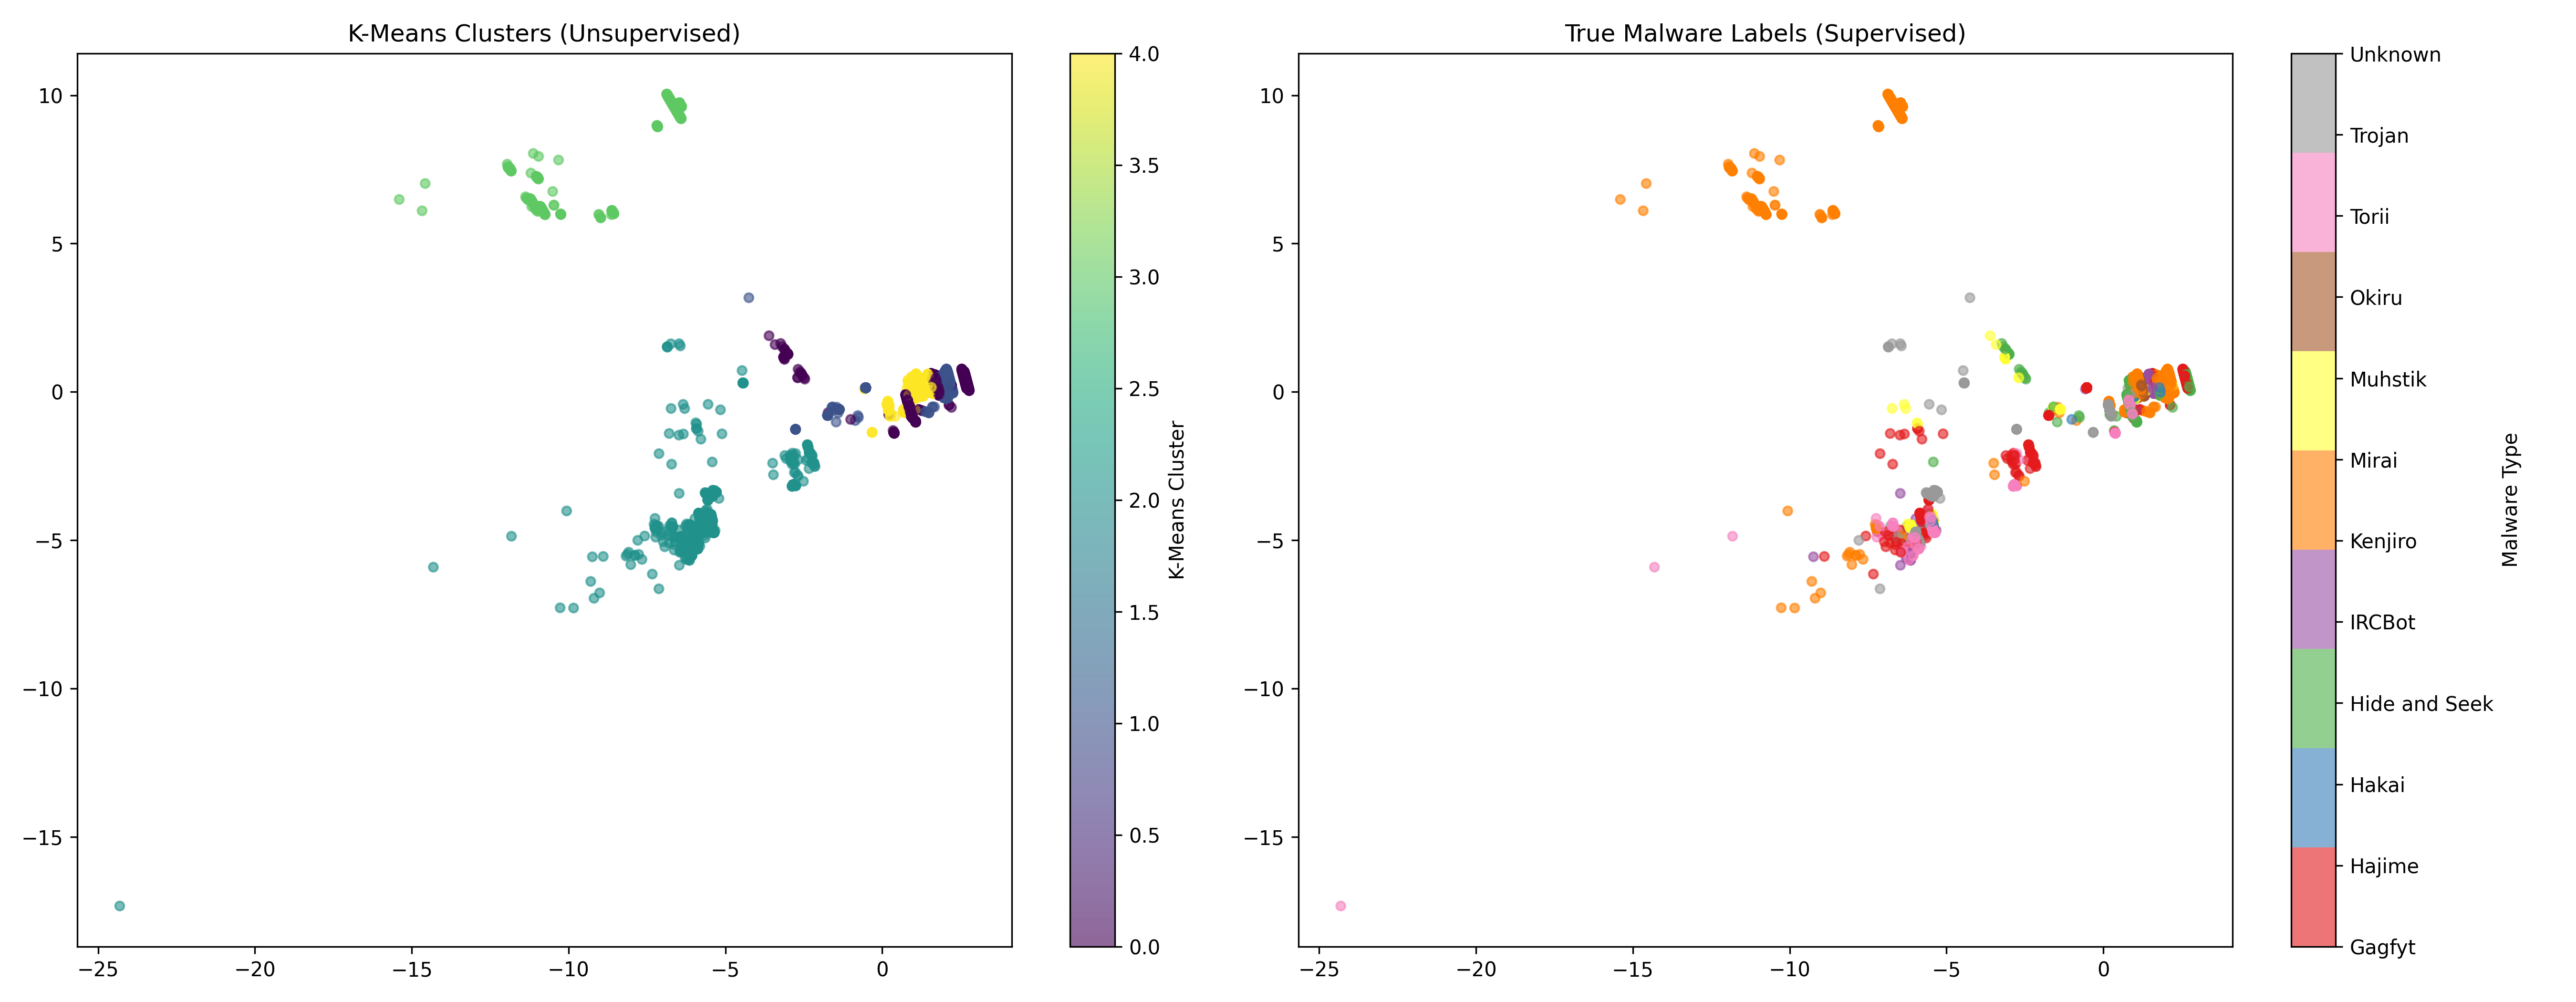

In [5]:
# %%
# ===================================================================
# CELL 6: VISUALIZE CLUSTERING ON TEST DATA (WITH PLOT DISPLAYED)
# ===================================================================
# Imports needed to display plots in the notebook
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import LabelEncoder # Ensure this is imported

print("\n" + "=" * 70)
print("Visualizing K-Means Clustering on Test Data")
print("=" * 70)

try:
    # 1. Load the clustering model
    kmeans_model = KMeansClustering()
    
    # Define just the filename
    model_filename = 'kmeans_clustering.pkl'
    
    # The load_model function will build the path itself
    kmeans_model.load_model(model_filename)
    
    model_path_for_print = os.path.join(Config.MODELS_DIR, model_filename)
    print(f"✓ Clustering model loaded from {model_path_for_print}")

    # 2. Prepare malicious data from the test set
    df_test_full = load_master_test_set()
    malicious_test_df = df_test_full[df_test_full[Config.TARGET_COL] == 'Malicious'].copy()
    
    # Use the features the model was trained on
    X_malicious_test = malicious_test_df[kmeans_model.feature_names_in_]

    # 3. Get true labels and encode them
    true_labels_str = malicious_test_df[Config.FAMILY_TARGET_COL].fillna('Unknown').astype(str)
    le_virus_viz = LabelEncoder()
    true_labels_encoded = le_virus_viz.fit_transform(true_labels_str)
    label_names = le_virus_viz.classes_.tolist()

    print(f"\n✓ Prepared {len(X_malicious_test):,} malicious test samples for visualization.")
    
    # 4. Assign test data to clusters
    cluster_labels = kmeans_model.predict(X_malicious_test)
    kmeans_model.labels = cluster_labels

    # 5. Generate and save the visualization
    kmeans_model.visualize_clusters_by_label(
        X_malicious_test,
        true_labels_encoded,
        label_names=label_names,
        save_plot=True
    )
    print("\n✓ Clustering visualization complete and saved to the results directory.")
    
    # --- This new section displays the plot that was just saved ---
    print("\n--- K-Means Clustering Visualization ---")
    cluster_plot_path = os.path.join(Config.RESULTS_DIR, 'clusters_vs_true_labels.png')
    if os.path.exists(cluster_plot_path):
        display(Image(filename=cluster_plot_path))
    else:
        print(f"Plot not found at {cluster_plot_path}")

except Exception as e:
    print(f"❌ ERROR visualizing clusters: {e}")